# PCA-pair OP-map analysis — illustrative example + summaries

Uses the **compact** error file (`errors_compact_binsweep.pkl` from
`repack_binsweep.py`) and `pca_scores_binsweep.pkl`.

Sections:
1. Example cell: real OP map **next to** the triangular PC-pair grid
   (upper = derived maps + per-pair percentile, diagonal = explained variance,
   lower = PC scatters), plus per-pair boxplots.
2. **Percentile grid** — the strict min-over-pairs uniform test (blue < 5%).
3. **Across-day stability** — per-pair percentile profiles per day, arrays with
   ≥ 25 oriented channels.
4. **EC vs EO** — for arrays significant in both, compare derived maps
   (own-best pair AND same shared pair) and which pairs win in each condition.

**Norm: L2 throughout.**

## Imports & compact data

In [1]:
import os, pickle
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib import gridspec

from functions_maps import (
    polar_angles_from_centroid, best_rotation_to_op, apply_geometric_map,
    map_errors, load_op_map,
)

with open("params_binsweep.yml") as f:
    P = yaml.safe_load(f)
DF_FOLDER = P["df_folder"]; LAYOUTS = P["layout"]; DATES = P["dates"]
MONKEYS = P["monkeys"]; N_CH = P["method"]["n_channels"]
OP_MAP_FOLDER = P["op_map_folder"]
SEL_MIN = P["channel_selection"]["selectivity_min"]
JUMP_MAX = P["channel_selection"]["num_jump_max"]
plt.rcParams["figure.facecolor"] = "white"

with open(os.path.join(DF_FOLDER, "errors_compact_binsweep.pkl"), "rb") as f:
    COMPACT = pickle.load(f)
with open(os.path.join(DF_FOLDER, "pca_scores_binsweep.pkl"), "rb") as f:
    PCA_STORE = pickle.load(f)
KEY_COLS = COMPACT["key_cols"]; REAL_DF = COMPACT["real"]; CTRL_VEC = COMPACT["ctrl"]
NORM = "L2"
print("real rows:", len(REAL_DF), "| ctrl keys:", len(CTRL_VEC),
      "| pca entries:", len(PCA_STORE))

real rows: 62076 | ctrl keys: 62076 | pca entries: 1512


## Shared helpers

In [2]:
HSV = plt.get_cmap("hsv"); UNI = np.array([0.5,0.5,0.5,1.0])

def get_layout(monkey, array):
    k = f"{monkey}_even" if int(array)%2==0 else f"{monkey}_odd"
    return np.array(LAYOUTS[k])

def pair_label(px, py): return f"PC{px+1} vs PC{py+1}"

def all_pairs(n_pc):
    return [(i,j) for i in range(n_pc) for j in range(i+1,n_pc)]

def load_op(monkey, array):
    return load_op_map(monkey, array, OP_MAP_FOLDER,
                       selectivity_min=SEL_MIN, num_jump_max=JUMP_MAX,
                       n_channels=N_CH)

def get_scores(monkey, date, array, condition, bin_ms):
    key = (monkey, str(date), int(array), condition, int(bin_ms))
    return PCA_STORE.get(key, None)

def derived_map(scores, oriented_idx, op_oriented, px, py):
    x, y = scores[:,px], scores[:,py]
    phi = polar_angles_from_centroid(x, y)
    rot, flip = best_rotation_to_op(phi, op_oriented)
    geo = apply_geometric_map(phi, rot, flip)
    d = np.full(N_CH, -1.0); d[oriented_idx] = geo
    return d

def real_err(monkey, date, array, condition, bin_ms, lab):
    m = ((REAL_DF.monkey==monkey)&(REAL_DF.date==str(date))&
         (REAL_DF.array==int(array))&(REAL_DF.condition==condition)&
         (REAL_DF.bin_ms==int(bin_ms))&(REAL_DF.pc_pair==lab)&(REAL_DF.norm==NORM))
    v = REAL_DF[m]["real_error"]
    return float(v.iloc[0]) if len(v) else np.nan

def ctrl_arr(monkey, date, array, condition, bin_ms, lab):
    k = (monkey, str(date), int(array), condition, int(bin_ms), lab, NORM)
    return CTRL_VEC.get(k, np.array([]))

def per_pair_percentile(monkey, date, array, condition, bin_ms, n_pc):
    """dict {(px,py): (real_err, percentile, ctrl_vec)} for all pairs."""
    out = {}
    for (px,py) in all_pairs(n_pc):
        lab = pair_label(px,py)
        re = real_err(monkey,date,array,condition,bin_ms,lab)
        cv = ctrl_arr(monkey,date,array,condition,bin_ms,lab)
        pct = 100.0*np.mean(cv<=re) if (len(cv) and not np.isnan(re)) else np.nan
        out[(px,py)] = (re, pct, cv)
    return out

def draw_op_grid(ax, vals, layout, title="", fontsize=9, grid_lines=True):
    gr = layout.shape; img = np.ones((*gr,4))
    for r in range(gr[0]):
        for c in range(gr[1]):
            ch = layout[r,c]; a = vals[ch] if 0<=ch<len(vals) else -1
            img[r,c] = UNI if a<0 else HSV((a%180)/180.0)
    ax.imshow(img, interpolation="nearest")
    if grid_lines:
        for i in range(gr[1]+1): ax.axvline(i-0.5,color="white",lw=0.4)
        for i in range(gr[0]+1): ax.axhline(i-0.5,color="white",lw=0.4)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, fontsize=fontsize)

def minpair_percentile(monkey, date, array, condition, bin_ms, n_pc):
    """Strict test: real min-over-pairs vs control min-over-pairs."""
    pairs = all_pairs(n_pc)
    real_vals = [real_err(monkey,date,array,condition,bin_ms,pair_label(*p)) for p in pairs]
    real_vals = [v for v in real_vals if not np.isnan(v)]
    if not real_vals: return np.nan
    real_min = np.min(real_vals)
    ctrl_stack = []
    for p in pairs:
        cv = ctrl_arr(monkey,date,array,condition,bin_ms,pair_label(*p))
        if len(cv): ctrl_stack.append(cv)
    if not ctrl_stack: return np.nan
    L = min(len(c) for c in ctrl_stack)
    null_min = np.min(np.vstack([c[:L] for c in ctrl_stack]), axis=0)
    return 100.0*np.mean(null_min <= real_min)

# 1. Example cell — real map beside the triangular grid

In [3]:
EX_MONKEY="L"; EX_DATE=DATES["L"]["RS"][1]; EX_ARRAY=16
EX_COND="all"; EX_BIN=100; N_PC=7

st = get_scores(EX_MONKEY,EX_DATE,EX_ARRAY,EX_COND,EX_BIN)
assert st is not None, "no PCA scores for this cell"
scores, oriented_idx, evr = st["scores"], st["oriented_idx"], st["evr"]
n_pc = min(N_PC, scores.shape[1])
op_full = load_op(EX_MONKEY, EX_ARRAY); op_oriented = op_full[oriented_idx]
layout = get_layout(EX_MONKEY, EX_ARRAY)

pp = per_pair_percentile(EX_MONKEY,EX_DATE,EX_ARRAY,EX_COND,EX_BIN,n_pc)
DERIVED = {(px,py): derived_map(scores,oriented_idx,op_oriented,px,py)
           for (px,py) in all_pairs(n_pc)}
print(f"cell {EX_MONKEY} {EX_DATE} arr{EX_ARRAY} {EX_COND} bin{EX_BIN} | "
      f"oriented {len(oriented_idx)} | PCs {n_pc}")

cell L 20170809 arr16 all bin100 | oriented 33 | PCs 7


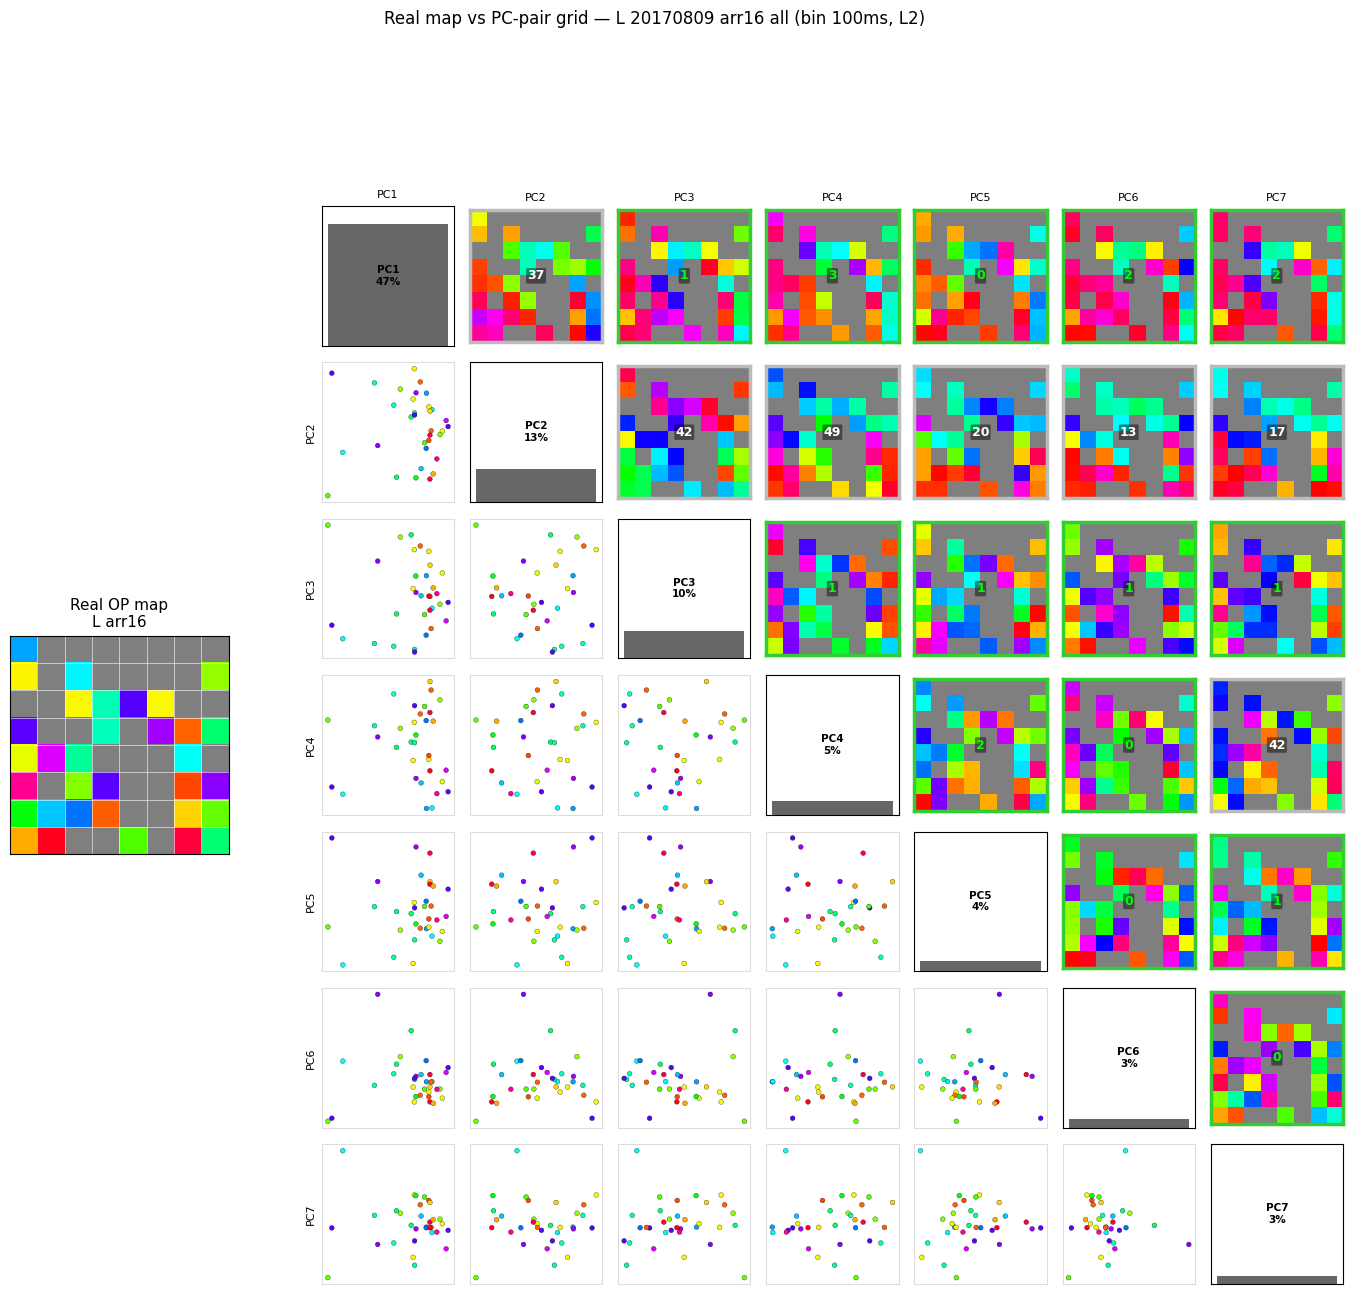

In [4]:
# figure: left column = real map; right = n_pc x n_pc triangle
fig = plt.figure(figsize=(2.0*n_pc + 3.2, 2.0*n_pc))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.0, 2.0*n_pc], wspace=0.15)
# real map panel
ax_real = fig.add_subplot(gs[0])
draw_op_grid(ax_real, op_full, layout,
             title=f"Real OP map\n{EX_MONKEY} arr{EX_ARRAY}", fontsize=11)
# triangle sub-grid
gs_tri = gridspec.GridSpecFromSubplotSpec(n_pc, n_pc, subplot_spec=gs[1],
                                          wspace=0.12, hspace=0.12)
def op_panel(ax, derived, pct):
    gr = layout.shape; img = np.ones((*gr,4))
    for r in range(gr[0]):
        for c in range(gr[1]):
            ch=layout[r,c]; a=derived[ch] if 0<=ch<len(derived) else -1
            img[r,c]=UNI if a<0 else HSV((a%180)/180.0)
    ax.imshow(img, interpolation="nearest"); ax.set_xticks([]); ax.set_yticks([])
    sig=(not np.isnan(pct)) and pct<5
    ax.text(0.5,0.5,"n/a" if np.isnan(pct) else f"{pct:.0f}",transform=ax.transAxes,
            ha="center",va="center",fontsize=9,fontweight="bold",
            color="lime" if sig else "white",
            bbox=dict(boxstyle="round,pad=0.1",fc="black",alpha=0.45,ec="none"))
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_linewidth(2.5)
        sp.set_edgecolor("limegreen" if sig else "#bbbbbb")
for r in range(n_pc):
    for c in range(n_pc):
        ax = fig.add_subplot(gs_tri[r, c])
        if r==c:
            ax.bar([0],[evr[r]],color="#666666",width=0.6)
            ax.set_ylim(0,max(evr[:n_pc])*1.15); ax.set_xticks([]); ax.set_yticks([])
            ax.text(0.5,0.5,f"PC{r+1}\n{evr[r]*100:.0f}%",transform=ax.transAxes,
                    ha="center",va="center",fontsize=7.5,fontweight="bold")
        elif r<c:
            op_panel(ax, DERIVED[(r,c)], pp[(r,c)][1])
        else:
            ax.scatter(scores[:,c],scores[:,r],c=HSV((op_oriented%180)/180.0),
                       s=12,edgecolor="k",linewidth=0.2)
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values(): sp.set_edgecolor("#dddddd")
        if r==0: ax.set_title(f"PC{c+1}",fontsize=8)
        if c==0 and r!=0: ax.set_ylabel(f"PC{r+1}",fontsize=8)
fig.suptitle(f"Real map vs PC-pair grid — {EX_MONKEY} {EX_DATE} arr{EX_ARRAY} "
             f"{EX_COND} (bin {EX_BIN}ms, {NORM})", fontsize=12, y=1.02)
plt.show()

### Per-pair boxplots (same cell)

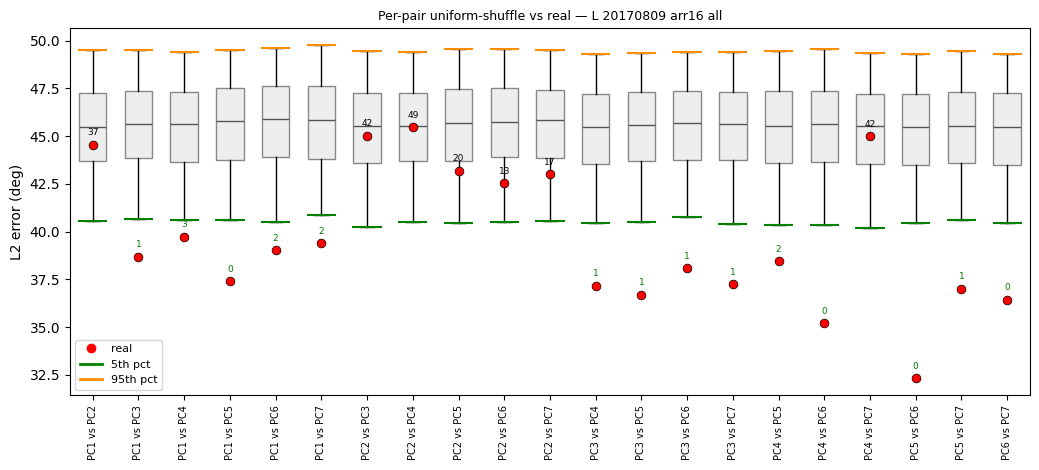

In [5]:
pairs = all_pairs(n_pc); labels=[pair_label(*p) for p in pairs]
cdat=[pp[p][2] for p in pairs]; rpts=[pp[p][0] for p in pairs]; pcts=[pp[p][1] for p in pairs]
fig, ax = plt.subplots(figsize=(max(8,len(pairs)*0.5),4.8))
bp=ax.boxplot(cdat,positions=range(len(pairs)),widths=0.6,whis=(5,95),
              showfliers=False,patch_artist=True)
for b in bp["boxes"]: b.set(facecolor="#eeeeee",edgecolor="#888888")
for mm in bp["medians"]: mm.set(color="#555555")
for i,cd in enumerate(cdat):
    if len(cd):
        ax.hlines(np.percentile(cd,5),i-0.32,i+0.32,color="green",lw=1.5,zorder=4)
        ax.hlines(np.percentile(cd,95),i-0.32,i+0.32,color="darkorange",lw=1.5,zorder=4)
for i,(re,pct) in enumerate(zip(rpts,pcts)):
    if not np.isnan(re):
        ax.scatter(i,re,color="red",s=40,zorder=5,edgecolor="k",linewidth=0.5)
        ax.annotate(f"{pct:.0f}",(i,re),textcoords="offset points",xytext=(0,7),
                    ha="center",fontsize=6.5,
                    color="green" if (not np.isnan(pct) and pct<5) else "black")
ax.set_xticks(range(len(pairs))); ax.set_xticklabels(labels,rotation=90,fontsize=7)
ax.set_ylabel(f"{NORM} error (deg)")
ax.set_title(f"Per-pair uniform-shuffle vs real — {EX_MONKEY} {EX_DATE} arr{EX_ARRAY} {EX_COND}",
             fontsize=9)
ax.legend(handles=[Line2D([0],[0],color="red",marker="o",ls="",label="real"),
                   Line2D([0],[0],color="green",lw=2,label="5th pct"),
                   Line2D([0],[0],color="darkorange",lw=2,label="95th pct")],fontsize=8)
plt.tight_layout(); plt.show()

# 2. Percentile grid — strict min-over-pairs uniform test

Per monkey, rows = arrays, cols = conditions, colour = strict min-over-pairs
percentile (blue < 5% beats control, diverging `bwr` centred on 5%).
Computed at the example bin `GRID_BIN`; change it to sweep.

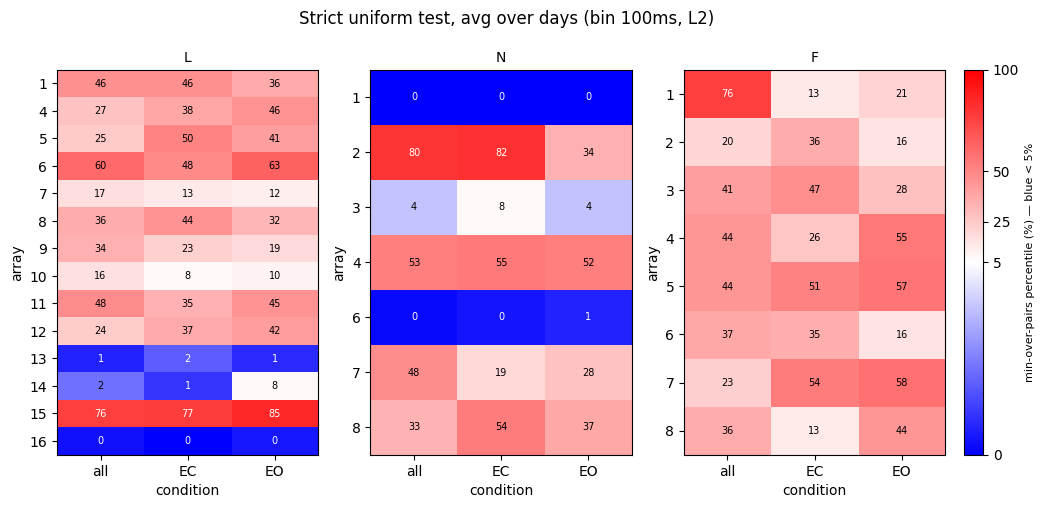

In [6]:
GRID_BIN = 100; N_PC_GRID = 7

def grid_for(monkey):
    arrays = sorted({int(a) for (m,d,a,c,b) in PCA_STORE if m==monkey and b==GRID_BIN})
    conds = ["all","EC","EO"]
    dates = DATES[monkey]["RS"]
    grid = np.full((len(arrays), len(conds)), np.nan)
    for i,arr in enumerate(arrays):
        for j,cond in enumerate(conds):
            vals=[]
            for dt in dates:
                if get_scores(monkey,dt,arr,cond,GRID_BIN) is None: continue
                p = minpair_percentile(monkey,dt,arr,cond,GRID_BIN,N_PC_GRID)
                if not np.isnan(p): vals.append(p)
            if vals: grid[i,j]=np.mean(vals)   # avg across days
    return arrays, conds, grid

fig, axes = plt.subplots(1, len(MONKEYS), figsize=(4.0*len(MONKEYS),5), squeeze=False)
im=None
for ax,monkey in zip(axes[0],MONKEYS):
    arrays,conds,grid = grid_for(monkey)
    im = ax.imshow(grid, cmap="bwr", norm=TwoSlopeNorm(vmin=0,vcenter=5,vmax=100),
                   aspect="auto")
    ax.set_xticks(range(len(conds))); ax.set_xticklabels(conds)
    ax.set_yticks(range(len(arrays))); ax.set_yticklabels(arrays)
    ax.set_xlabel("condition"); ax.set_ylabel("array"); ax.set_title(monkey,fontsize=10)
    for i in range(len(arrays)):
        for j in range(len(conds)):
            v=grid[i,j]
            if not np.isnan(v):
                ax.text(j,i,f"{v:.0f}",ha="center",va="center",fontsize=7,
                        color="white" if (v<2 or v>70) else "black")
cbar=fig.colorbar(im,ax=axes,fraction=0.025,pad=0.02,ticks=[0,5,25,50,100])
cbar.set_label("min-over-pairs percentile (%) — blue < 5%",fontsize=8)
fig.suptitle(f"Strict uniform test, avg over days (bin {GRID_BIN}ms, {NORM})",
             fontsize=12,y=1.0)
plt.show()

# 3. Across-day stability of per-pair information

For arrays with **≥ 25 oriented channels** and **more than one recording day**,
show the per-pair percentile profile (all 21 pairs) for each day side by side.
If the same pairs carry the map across days, the columns look alike.
Condition fixed to `STAB_COND`.

qualifying arrays: [('L', 1), ('L', 7), ('L', 9), ('L', 10), ('L', 11), ('L', 12), ('L', 13), ('L', 14), ('L', 16), ('N', 3), ('N', 6), ('F', 4)]


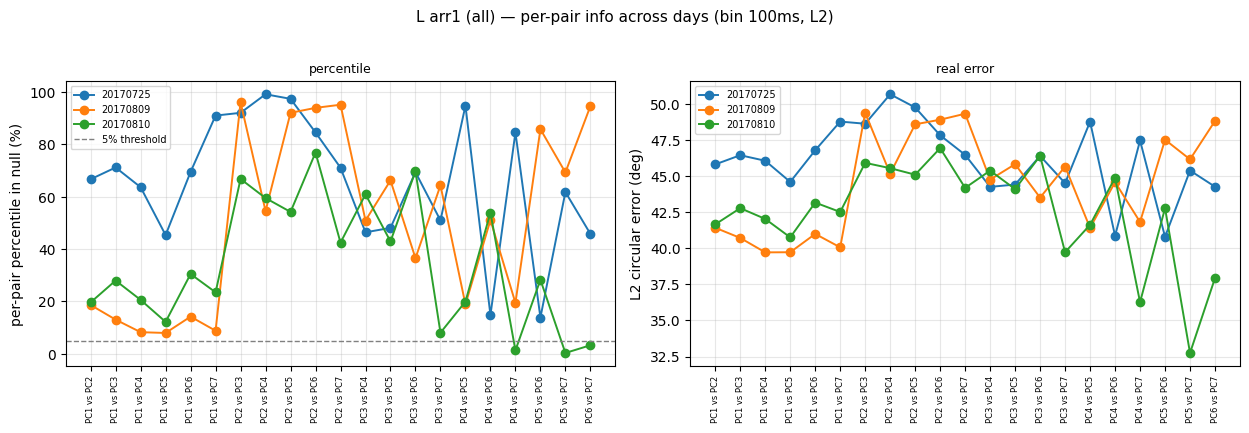

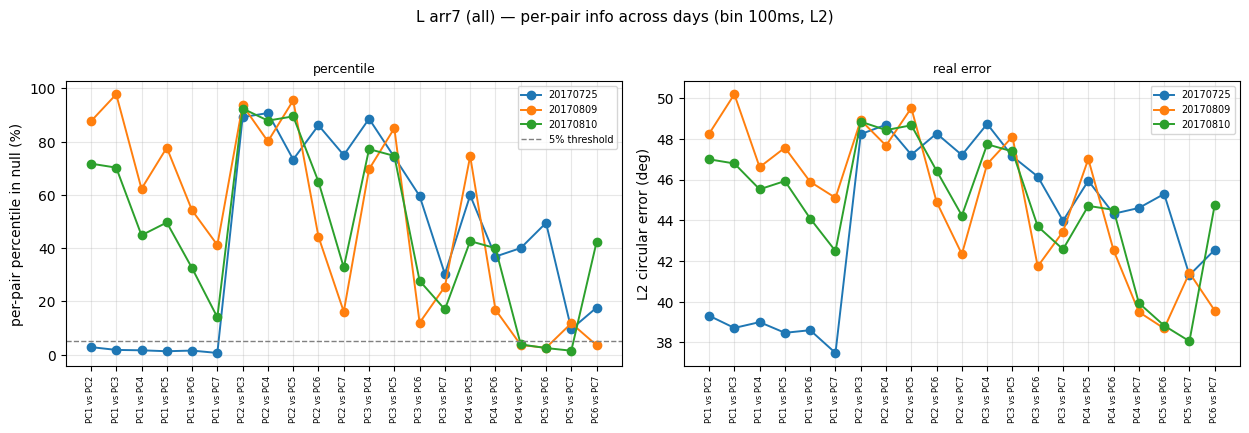

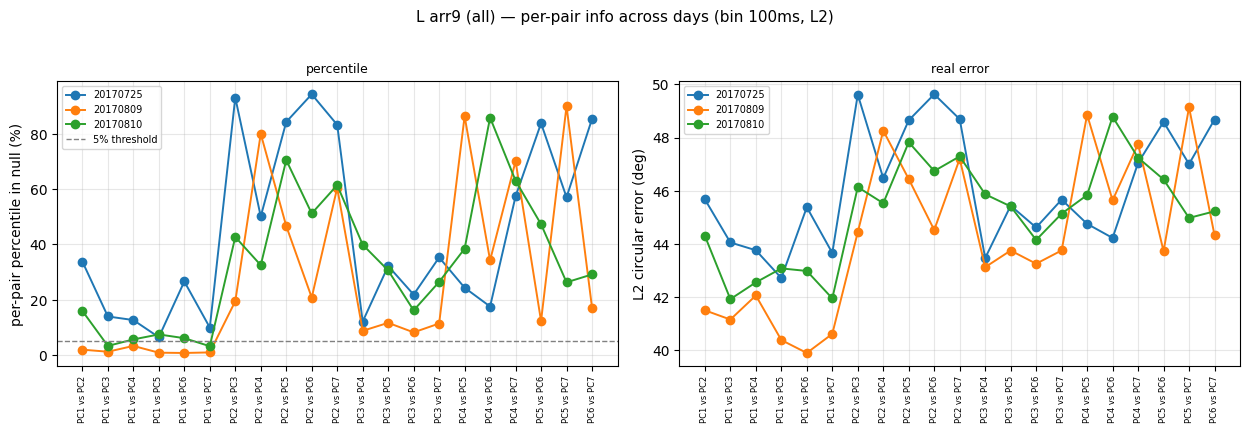

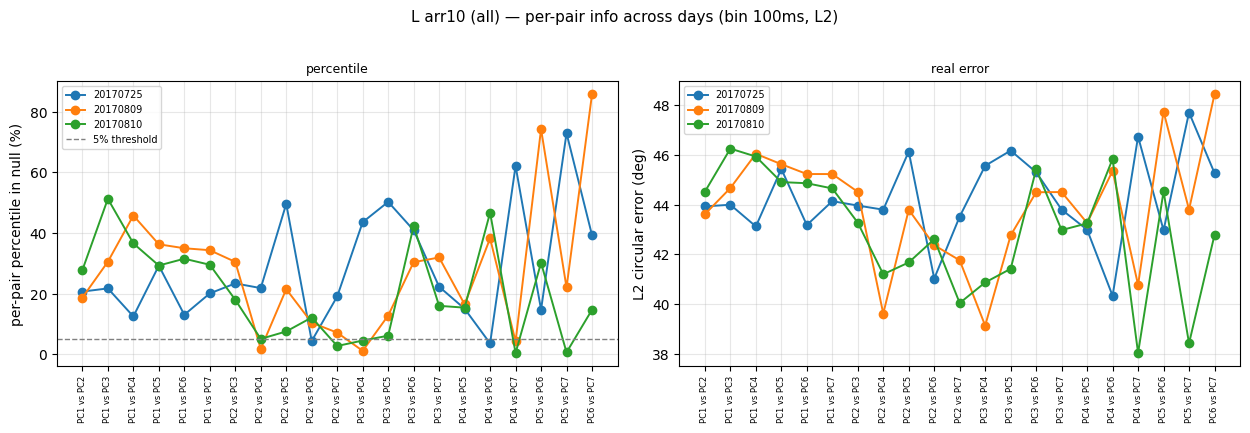

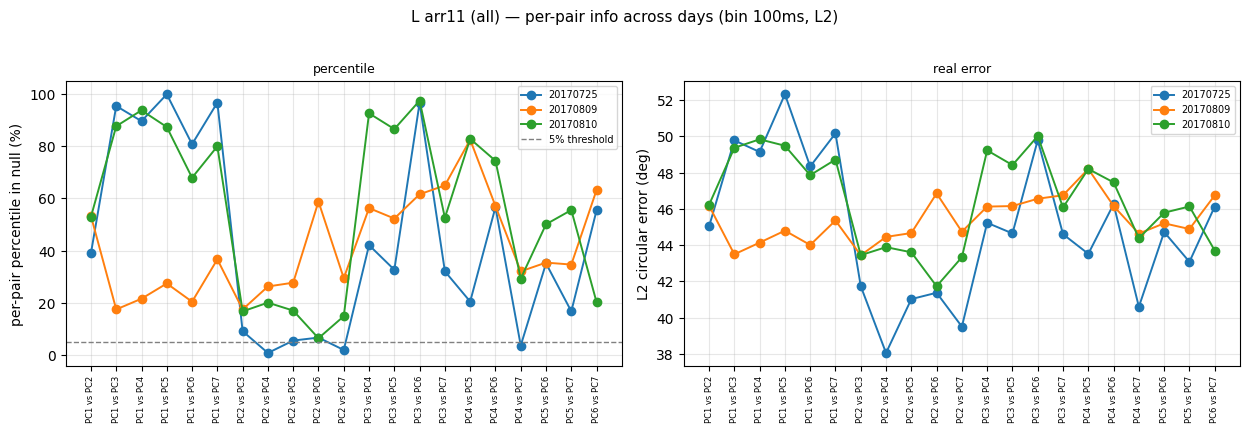

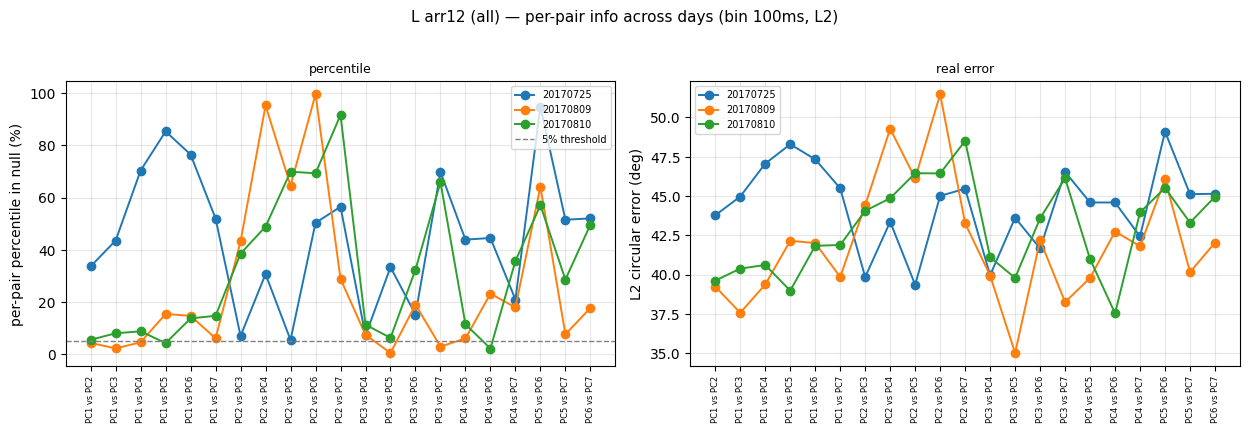

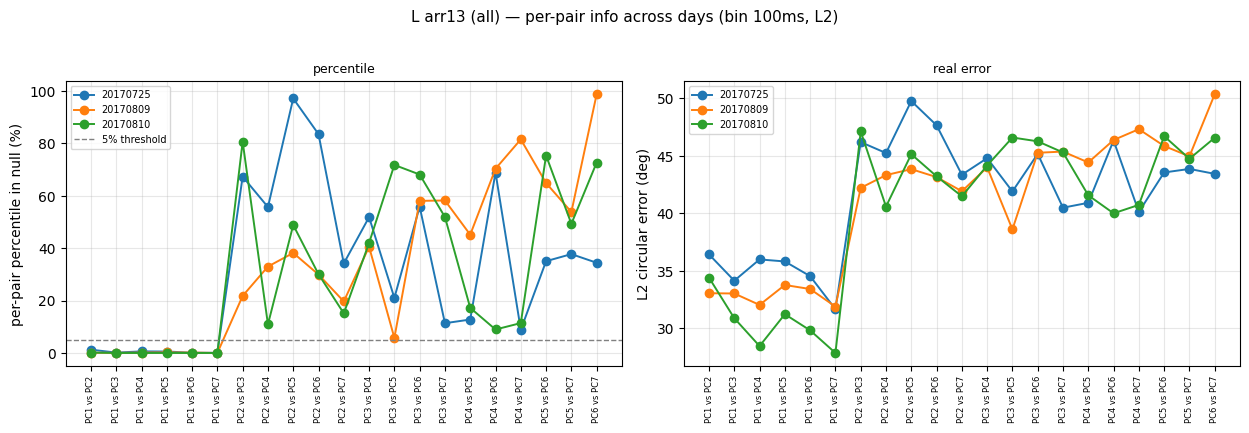

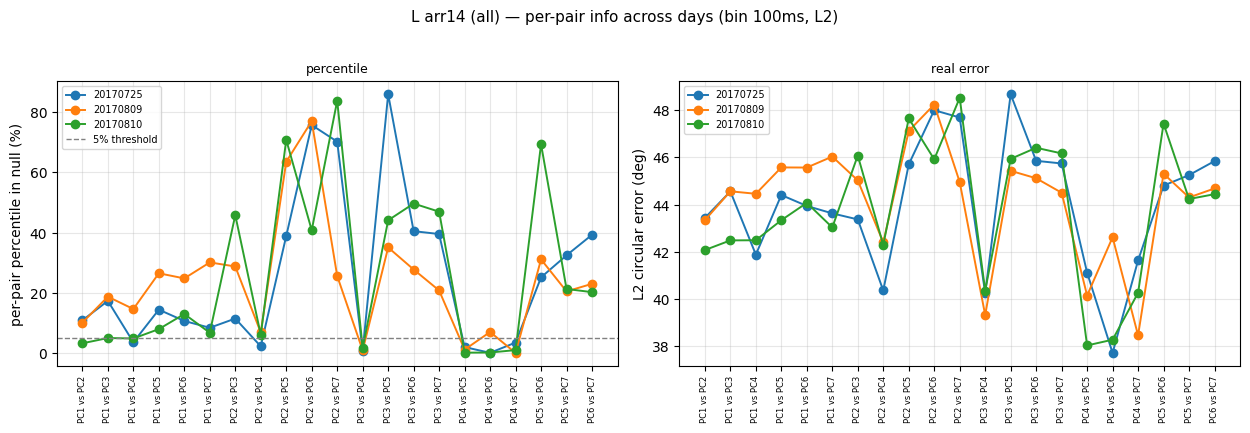

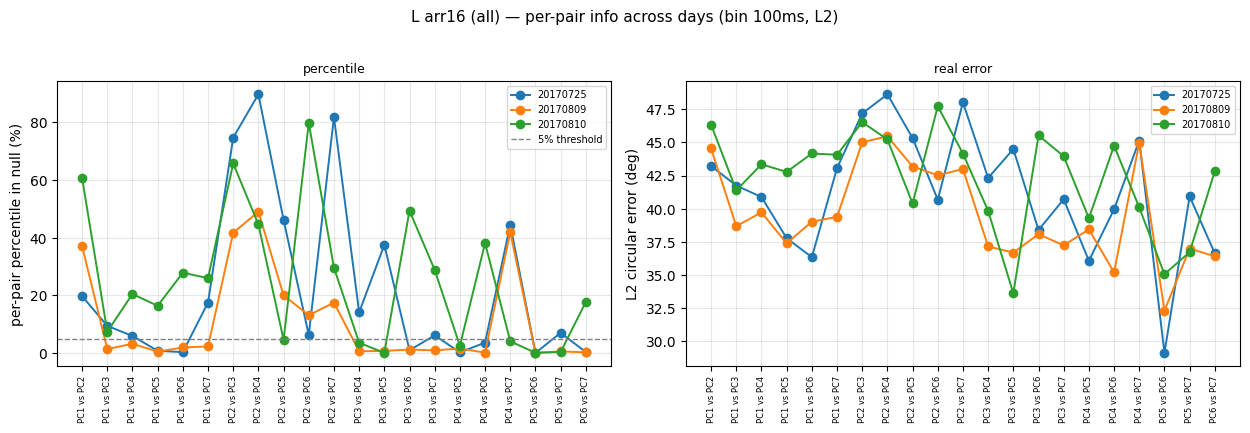

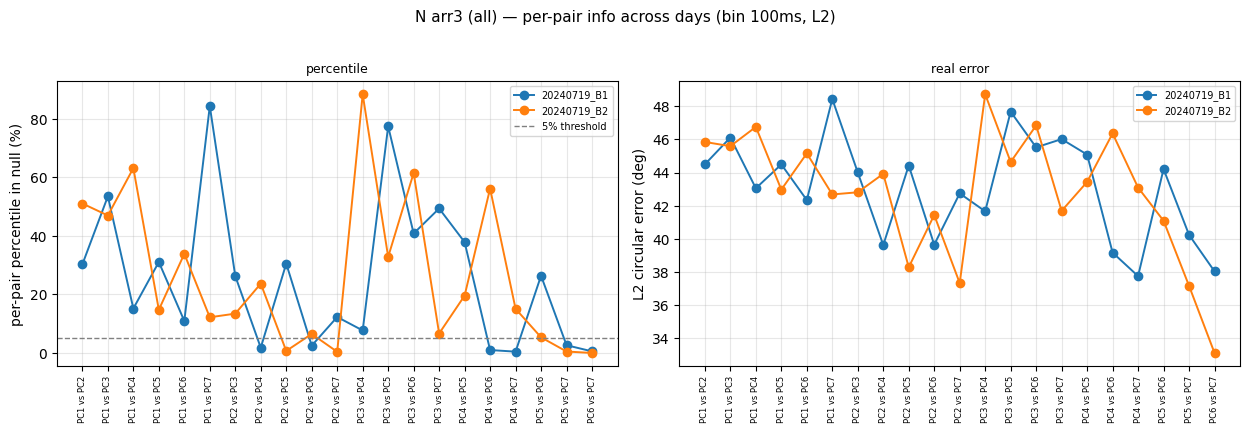

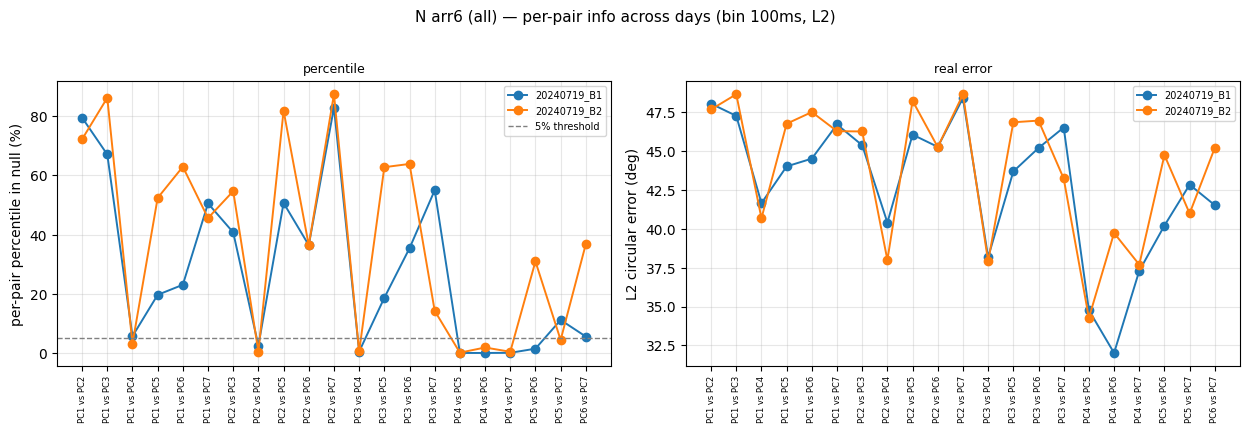

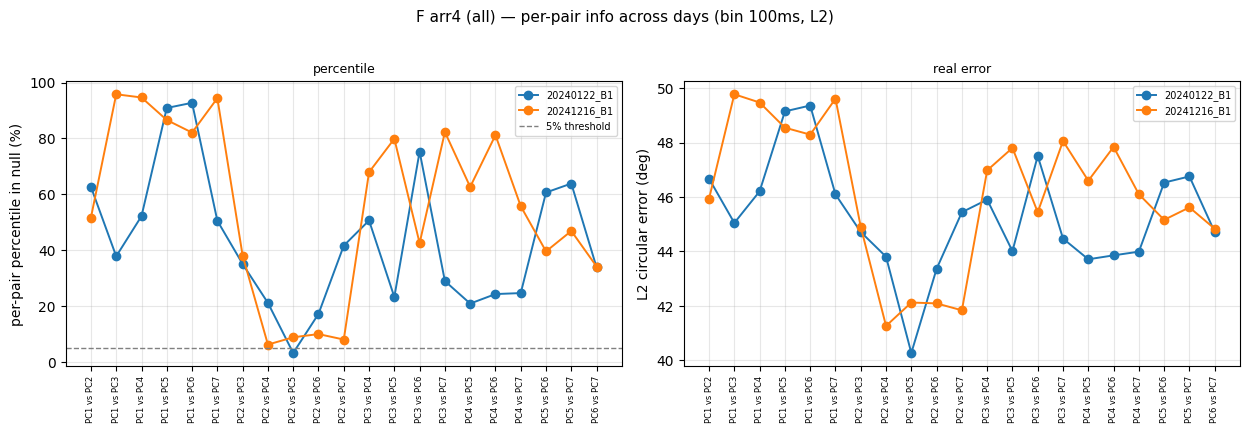

In [12]:
STAB_BIN=100; STAB_COND="all"; STAB_NPC=7; MIN_ORIENTED=25
stab_pairs = all_pairs(STAB_NPC); stab_labels=[pair_label(*p) for p in stab_pairs]

def n_oriented(monkey,array,bin_ms):
    for dt in DATES[monkey]["RS"]:
        for cond in ["all","EC","EO"]:
            st=get_scores(monkey,dt,array,cond,bin_ms)
            if st is not None: return len(st["oriented_idx"])
    return 0

# arrays qualifying: >=25 oriented AND >1 day present
qualifying=[]
for monkey in MONKEYS:
    arrays=sorted({int(a) for (m,d,a,c,b) in PCA_STORE if m==monkey and b==STAB_BIN})
    for arr in arrays:
        if n_oriented(monkey,arr,STAB_BIN) < MIN_ORIENTED: continue
        days=[dt for dt in DATES[monkey]["RS"]
              if get_scores(monkey,dt,arr,STAB_COND,STAB_BIN) is not None]
        if len(days)>1: qualifying.append((monkey,arr,days))
print("qualifying arrays:", [(m,a) for (m,a,_) in qualifying])

for (monkey,arr,days) in qualifying:
    x = range(len(stab_pairs))
    # per-pair percentile and error per day
    pct = {dt: [] for dt in days}; err = {dt: [] for dt in days}
    for dt in days:
        pp = per_pair_percentile(monkey,dt,arr,STAB_COND,STAB_BIN,STAB_NPC)
        pct[dt] = [pp[p][1] for p in stab_pairs]
        err[dt] = [pp[p][0] for p in stab_pairs]

    fig, (axp, axe) = plt.subplots(1, 2, figsize=(max(9, len(stab_pairs)*0.6), 4.2))

    # left: percentiles
    for dt in days:
        axp.plot(x, pct[dt], marker="o", lw=1.4, label=dt)
    axp.axhline(5, color="grey", ls="--", lw=1, label="5% threshold")
    axp.set_xticks(list(x)); axp.set_xticklabels(stab_labels, rotation=90, fontsize=6)
    axp.set_ylabel("per-pair percentile in null (%)")
    axp.set_title("percentile", fontsize=9)
    axp.legend(fontsize=7); axp.grid(alpha=0.3)

    # right: real errors
    for dt in days:
        axe.plot(x, err[dt], marker="o", lw=1.4, label=dt)
    axe.set_xticks(list(x)); axe.set_xticklabels(stab_labels, rotation=90, fontsize=6)
    axe.set_ylabel(f"{NORM} circular error (deg)")
    axe.set_title("real error", fontsize=9)
    axe.legend(fontsize=7); axe.grid(alpha=0.3)

    fig.suptitle(f"{monkey} arr{arr} ({STAB_COND}) — per-pair info across days "
                 f"(bin {STAB_BIN}ms, {NORM})", fontsize=11, y=1.02)
    plt.tight_layout(); plt.show()

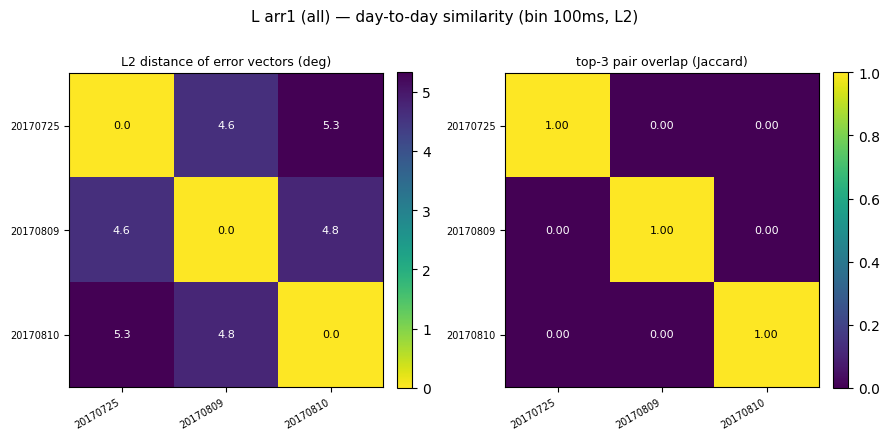

L arr1 best single pair per day: {'20170725': 'PC5 vs PC6', '20170809': 'PC1 vs PC4', '20170810': 'PC5 vs PC7'}


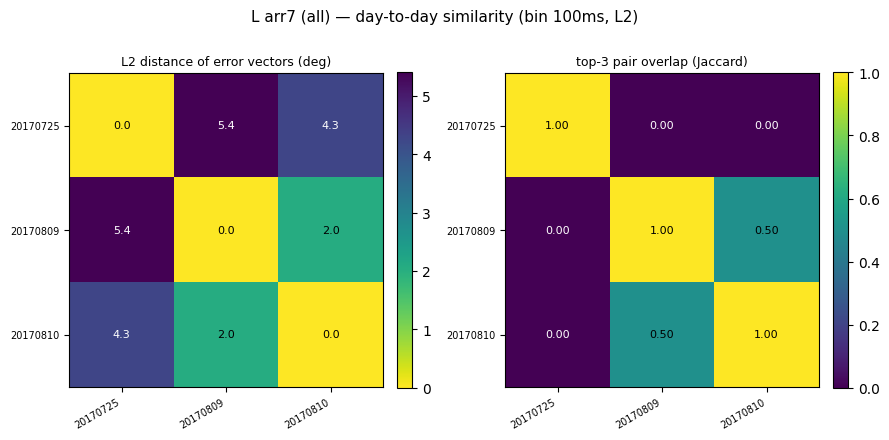

L arr7 best single pair per day: {'20170725': 'PC1 vs PC7', '20170809': 'PC5 vs PC6', '20170810': 'PC5 vs PC7'}


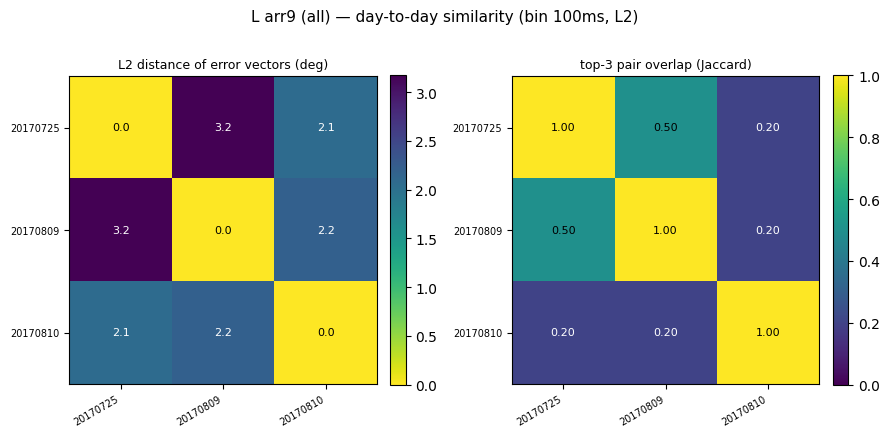

L arr9 best single pair per day: {'20170725': 'PC1 vs PC5', '20170809': 'PC1 vs PC6', '20170810': 'PC1 vs PC3'}


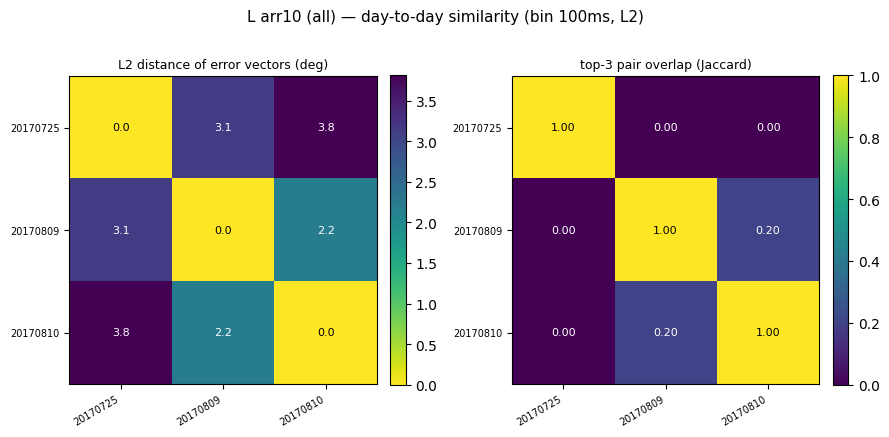

L arr10 best single pair per day: {'20170725': 'PC4 vs PC6', '20170809': 'PC3 vs PC4', '20170810': 'PC4 vs PC7'}


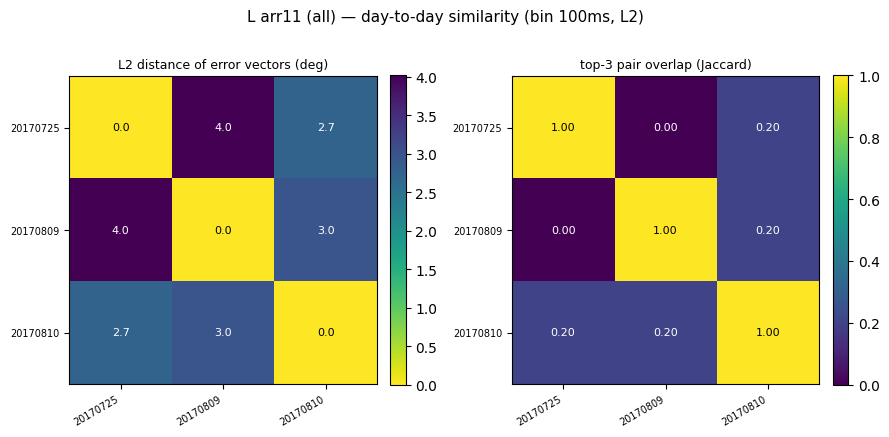

L arr11 best single pair per day: {'20170725': 'PC2 vs PC4', '20170809': 'PC2 vs PC3', '20170810': 'PC2 vs PC6'}


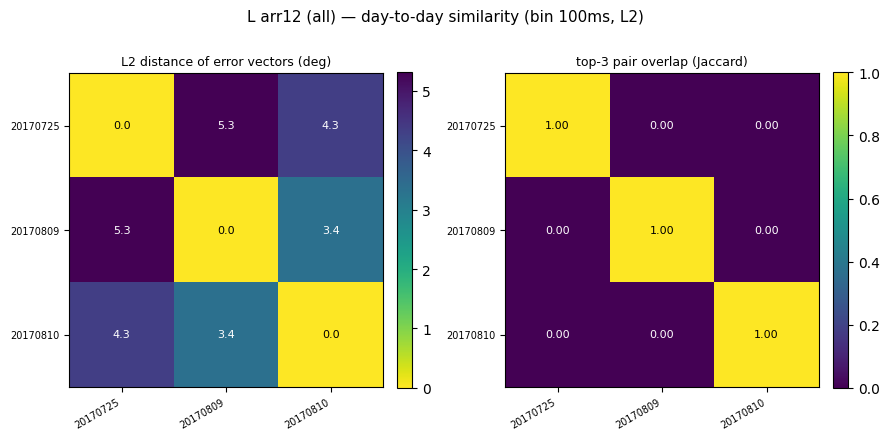

L arr12 best single pair per day: {'20170725': 'PC2 vs PC5', '20170809': 'PC3 vs PC5', '20170810': 'PC4 vs PC6'}


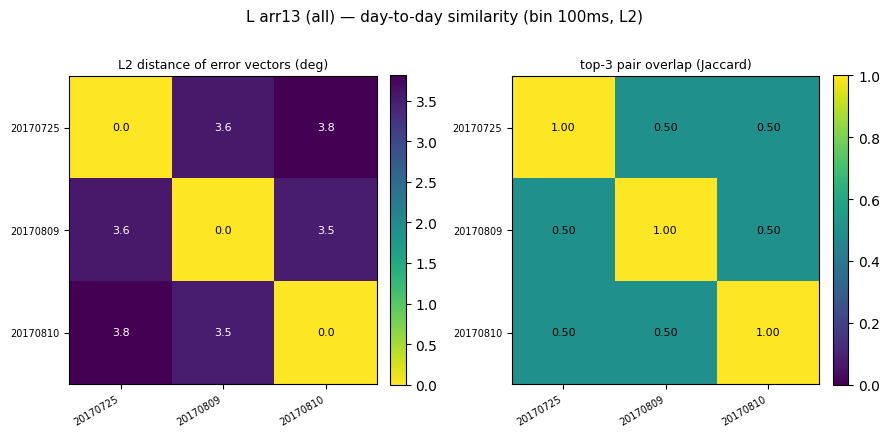

L arr13 best single pair per day: {'20170725': 'PC1 vs PC7', '20170809': 'PC1 vs PC7', '20170810': 'PC1 vs PC7'}


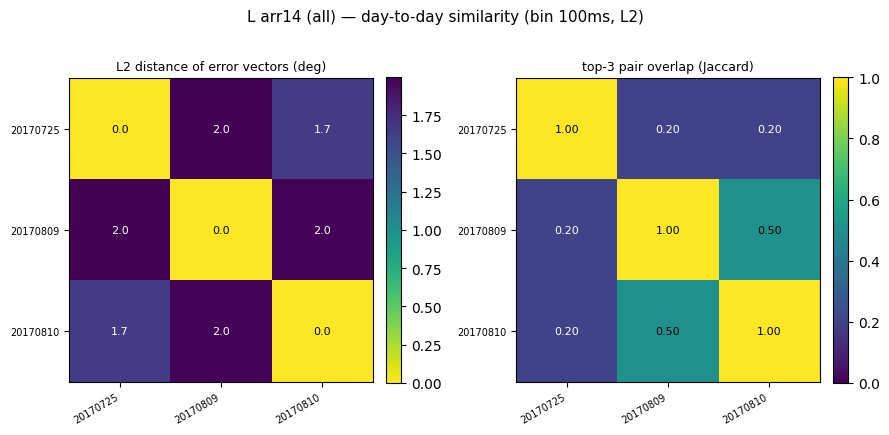

L arr14 best single pair per day: {'20170725': 'PC4 vs PC6', '20170809': 'PC4 vs PC7', '20170810': 'PC4 vs PC5'}


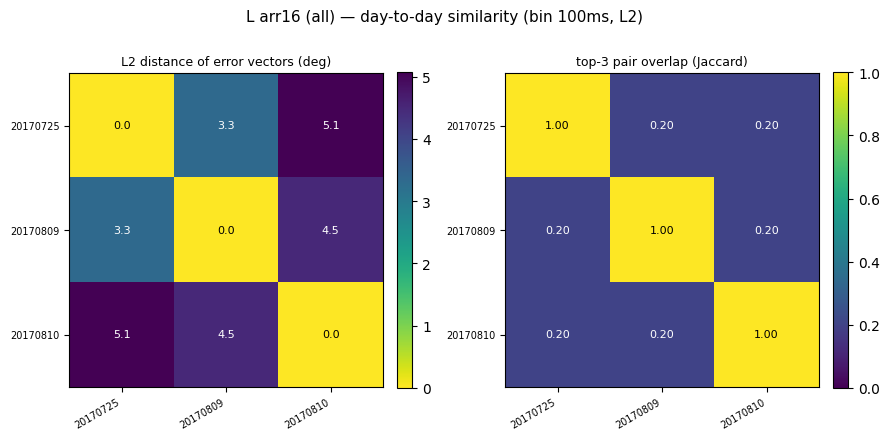

L arr16 best single pair per day: {'20170725': 'PC5 vs PC6', '20170809': 'PC5 vs PC6', '20170810': 'PC3 vs PC5'}


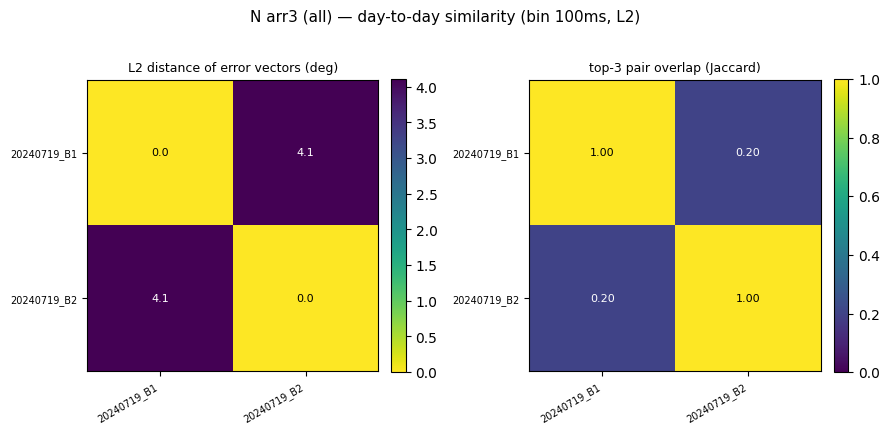

N arr3 best single pair per day: {'20240719_B1': 'PC4 vs PC7', '20240719_B2': 'PC6 vs PC7'}


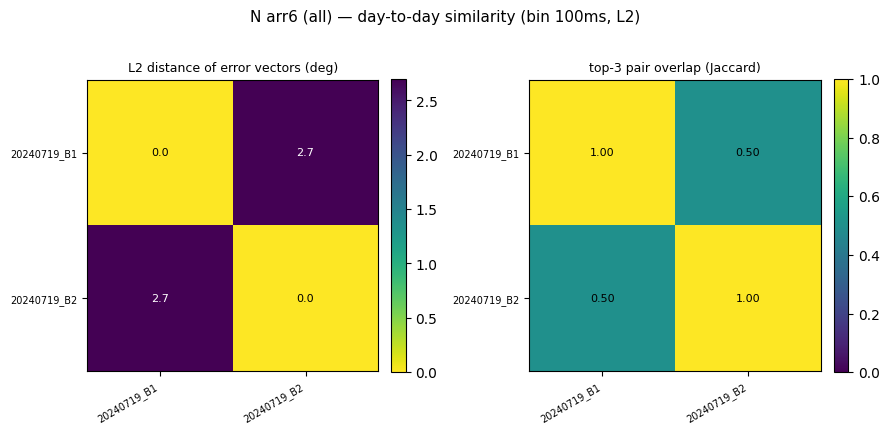

N arr6 best single pair per day: {'20240719_B1': 'PC4 vs PC6', '20240719_B2': 'PC4 vs PC5'}


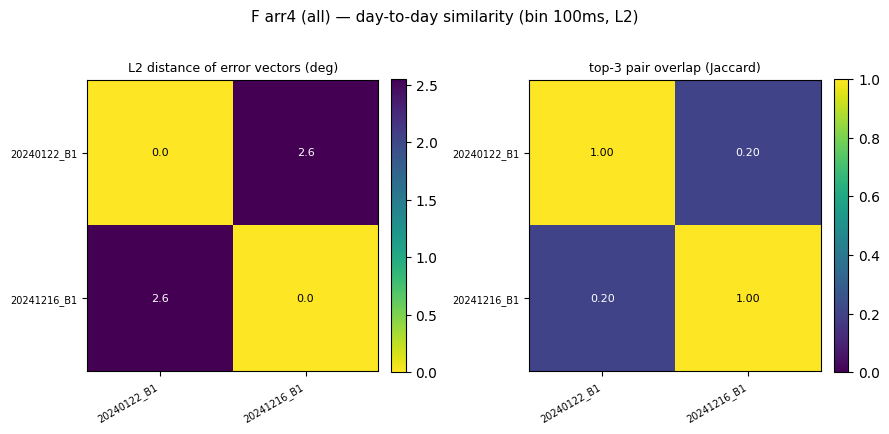

F arr4 best single pair per day: {'20240122_B1': 'PC2 vs PC5', '20241216_B1': 'PC2 vs PC4'}


In [13]:
TOPK = 3   # for winning-pair overlap

def day_error_vector(monkey, dt, arr):
    pp = per_pair_percentile(monkey, dt, arr, STAB_COND, STAB_BIN, STAB_NPC)
    return np.array([pp[p][0] for p in stab_pairs])   # real L2 error per pair

def topk_set(err_vec, k=TOPK):
    return set(np.argsort(err_vec)[:k])               # indices of k lowest-error pairs

for (monkey, arr, days) in qualifying:
    evecs = {dt: day_error_vector(monkey, dt, arr) for dt in days}
    tops  = {dt: topk_set(evecs[dt]) for dt in days}
    n = len(days)

    L2 = np.full((n, n), np.nan)       # option 2: L2 distance between error vectors
    JAC = np.full((n, n), np.nan)      # option 3: Jaccard of top-k pairs
    for i, di in enumerate(days):
        for j, dj in enumerate(days):
            v = ~np.isnan(evecs[di]) & ~np.isnan(evecs[dj])
            L2[i, j] = np.sqrt(np.mean((evecs[di][v] - evecs[dj][v])**2))
            inter = len(tops[di] & tops[dj]); union = len(tops[di] | tops[dj])
            JAC[i, j] = inter / union if union else np.nan

    fig, (axd, axj) = plt.subplots(1, 2, figsize=(9, 4.2))

    imd = axd.imshow(L2, cmap="viridis_r")     # lower distance = more similar = brighter
    axd.set_title(f"L2 distance of error vectors (deg)", fontsize=9)
    for i in range(n):
        for j in range(n):
            if not np.isnan(L2[i, j]):
                axd.text(j, i, f"{L2[i,j]:.1f}", ha="center", va="center",
                         fontsize=8, color="white" if L2[i,j] > np.nanmean(L2) else "black")
    fig.colorbar(imd, ax=axd, fraction=0.046, pad=0.04)

    imj = axj.imshow(JAC, cmap="viridis", vmin=0, vmax=1)   # higher overlap = more similar
    axj.set_title(f"top-{TOPK} pair overlap (Jaccard)", fontsize=9)
    for i in range(n):
        for j in range(n):
            if not np.isnan(JAC[i, j]):
                axj.text(j, i, f"{JAC[i,j]:.2f}", ha="center", va="center",
                         fontsize=8, color="white" if JAC[i,j] < 0.5 else "black")
    fig.colorbar(imj, ax=axj, fraction=0.046, pad=0.04)

    for ax in (axd, axj):
        ax.set_xticks(range(n)); ax.set_xticklabels(days, rotation=30, fontsize=7, ha="right")
        ax.set_yticks(range(n)); ax.set_yticklabels(days, fontsize=7)

    fig.suptitle(f"{monkey} arr{arr} ({STAB_COND}) — day-to-day similarity "
                 f"(bin {STAB_BIN}ms, {NORM})", fontsize=11, y=1.02)
    plt.tight_layout(); plt.show()

    # quick textual read-out of best single pair per day
    best_single = {dt: pair_label(*stab_pairs[int(np.nanargmin(evecs[dt]))]) for dt in days}
    print(f"{monkey} arr{arr} best single pair per day:",
          {dt: best_single[dt] for dt in days})

pooled rows: 30


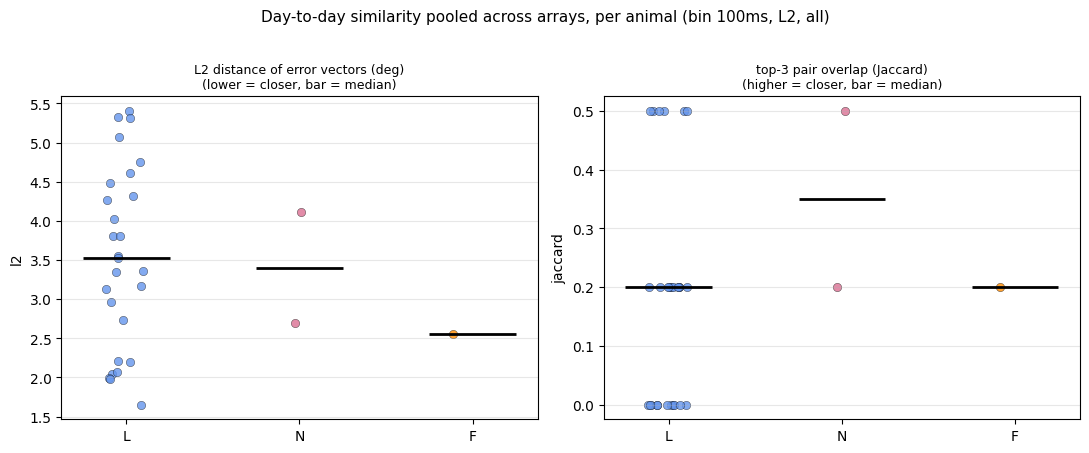

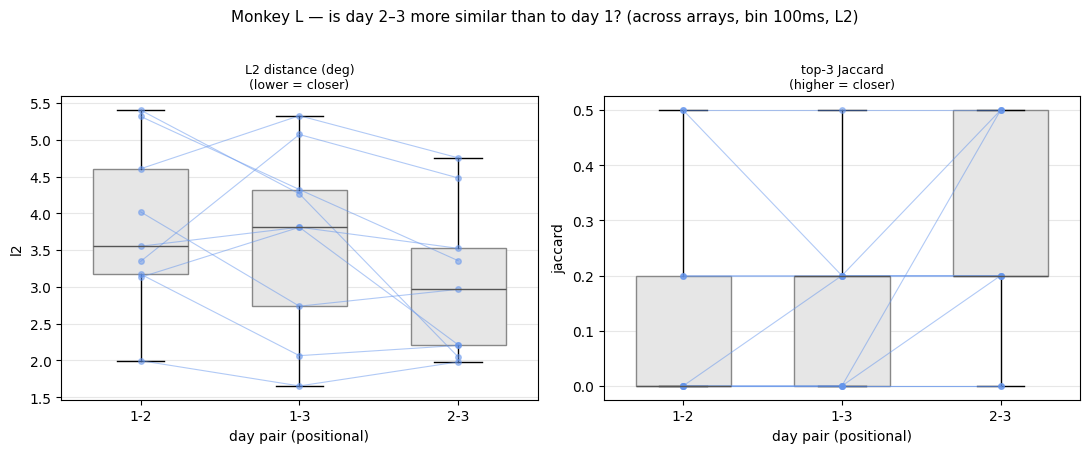

Monkey L median by day-pair:
                l2  jaccard
day_pair                   
1-2       3.552872      0.0
1-3       3.810974      0.2
2-3       2.966401      0.2


In [15]:
# ---- pool day-to-day similarity across arrays, per animal ----
TOPK_POOL = TOPK   # same k as the per-array cell
COLORS_M = P["colors_monkeys"]

pool = []   # one row per (animal, array, day-pair)
for (monkey, arr, days) in qualifying:
    evecs = {dt: day_error_vector(monkey, dt, arr) for dt in days}
    tops  = {dt: topk_set(evecs[dt], TOPK_POOL) for dt in days}
    for i in range(len(days)):
        for j in range(i+1, len(days)):
            di, dj = days[i], days[j]
            v = ~np.isnan(evecs[di]) & ~np.isnan(evecs[dj])
            l2 = np.sqrt(np.mean((evecs[di][v] - evecs[dj][v])**2))
            inter = len(tops[di] & tops[dj]); union = len(tops[di] | tops[dj])
            jac = inter/union if union else np.nan
            pool.append(dict(monkey=monkey, array=arr,
                             day_i=di, day_j=dj,
                             day_pair=f"{i+1}-{j+1}",   # positional: 1-2, 1-3, 2-3
                             l2=l2, jaccard=jac))
pool = pd.DataFrame(pool)
print("pooled rows:", len(pool))

# === Plot A: per-animal distribution across arrays (all day-pairs pooled) ===
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, col, name, better in [
        (axes[0], "l2", "L2 distance of error vectors (deg)", "lower = closer"),
        (axes[1], "jaccard", f"top-{TOPK_POOL} pair overlap (Jaccard)", "higher = closer")]:
    for k, monkey in enumerate(MONKEYS):
        vals = pool[pool.monkey == monkey][col].dropna().values
        if not len(vals):
            continue
        xj = np.full(len(vals), k) + np.random.uniform(-0.12, 0.12, len(vals))
        ax.scatter(xj, vals, color=COLORS_M.get(monkey, "gray"), s=36,
                   alpha=0.8, edgecolor="k", linewidth=0.3)
        ax.hlines(np.median(vals), k-0.25, k+0.25, color="black", lw=2, zorder=5)
    ax.set_xticks(range(len(MONKEYS))); ax.set_xticklabels(MONKEYS)
    ax.set_ylabel(col); ax.set_title(f"{name}\n({better}, bar = median)", fontsize=9)
    ax.grid(alpha=0.3, axis="y")
fig.suptitle(f"Day-to-day similarity pooled across arrays, per animal "
             f"(bin {STAB_BIN}ms, {NORM}, {STAB_COND})", fontsize=11, y=1.02)
plt.tight_layout(); plt.show()

# === Plot B: L only — compare the three day-pair types across its arrays ===
L_pool = pool[pool.monkey == "L"]
if L_pool["day_pair"].nunique() > 1:
    order = ["1-2", "1-3", "2-3"]
    order = [o for o in order if o in L_pool["day_pair"].unique()]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
    for ax, col, name, better in [
            (axes[0], "l2", "L2 distance (deg)", "lower = closer"),
            (axes[1], "jaccard", f"top-{TOPK_POOL} Jaccard", "higher = closer")]:
        data = [L_pool[L_pool.day_pair == o][col].dropna().values for o in order]
        bp = ax.boxplot(data, positions=range(len(order)), widths=0.6,
                        showfliers=False, patch_artist=True)
        for b in bp["boxes"]: b.set(facecolor="#e6e6e6", edgecolor="#888")
        for med in bp["medians"]: med.set(color="#555")
        # overlay each array's points, lines connecting the same array across day-pairs
        arrays_L = sorted(L_pool.array.unique())
        for arr in arrays_L:
            ys = [L_pool[(L_pool.array==arr)&(L_pool.day_pair==o)][col].values for o in order]
            ys = [y[0] if len(y) else np.nan for y in ys]
            ax.plot(range(len(order)), ys, color="cornflowerblue", alpha=0.5,
                    marker="o", ms=4, lw=0.8)
        ax.set_xticks(range(len(order))); ax.set_xticklabels(order)
        ax.set_xlabel("day pair (positional)")
        ax.set_ylabel(col); ax.set_title(f"{name}\n({better})", fontsize=9)
        ax.grid(alpha=0.3, axis="y")
    fig.suptitle("Monkey L — is day 2–3 more similar than to day 1? "
                 f"(across arrays, bin {STAB_BIN}ms, {NORM})", fontsize=11, y=1.02)
    plt.tight_layout(); plt.show()

    # numeric summary
    print("Monkey L median by day-pair:")
    print(L_pool.groupby("day_pair")[["l2","jaccard"]].median().reindex(order))
else:
    print("Monkey L has only one day-pair — nothing to compare.")

# 4. EC vs EO — for arrays significant in both conditions

"Significant in both" = strict min-over-pairs percentile < 5 in **both** EC and
EO (same array/day/bin). For each such cell:
- compare derived maps: **own-best pair** per condition, and a **shared pair**
  (best pooled across the two conditions),
- list which pair wins in EC vs EO.

In [8]:
ECEO_BIN=100; ECEO_NPC=7; SIG=5.0
eceo_pairs=all_pairs(ECEO_NPC)

def best_pair(monkey,date,array,condition,bin_ms,n_pc):
    best=None; best_e=np.inf
    for p in all_pairs(n_pc):
        e=real_err(monkey,date,array,condition,bin_ms,pair_label(*p))
        if not np.isnan(e) and e<best_e: best_e=e; best=p
    return best, best_e

# find qualifying (monkey, date, array)
qual=[]
for monkey in MONKEYS:
    for dt in DATES[monkey]["RS"]:
        arrays=sorted({int(a) for (m,d,a,c,b) in PCA_STORE
                       if m==monkey and d==str(dt) and b==ECEO_BIN})
        for arr in arrays:
            if get_scores(monkey,dt,arr,"EC",ECEO_BIN) is None: continue
            if get_scores(monkey,dt,arr,"EO",ECEO_BIN) is None: continue
            pec=minpair_percentile(monkey,dt,arr,"EC",ECEO_BIN,ECEO_NPC)
            peo=minpair_percentile(monkey,dt,arr,"EO",ECEO_BIN,ECEO_NPC)
            if pec<SIG and peo<SIG: qual.append((monkey,dt,arr,pec,peo))
print("EC&EO significant cells:", [(m,d,a) for (m,d,a,_,_) in qual])

EC&EO significant cells: [('L', '20170725', 13), ('L', '20170725', 14), ('L', '20170725', 16), ('L', '20170809', 13), ('L', '20170809', 16), ('L', '20170810', 13), ('L', '20170810', 14), ('L', '20170810', 16), ('N', '20240719_B1', 1), ('N', '20240719_B1', 3), ('N', '20240719_B1', 6), ('N', '20240719_B2', 1), ('N', '20240719_B2', 6), ('F', '20241216_B1', 1)]


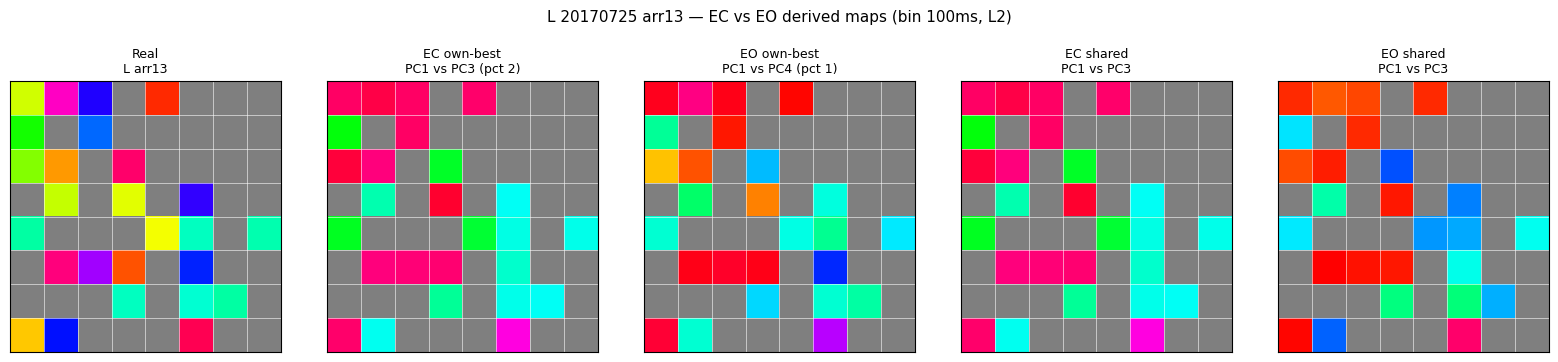

L 20170725 arr13: EC best PC1 vs PC3 | EO best PC1 vs PC4 | shared PC1 vs PC3


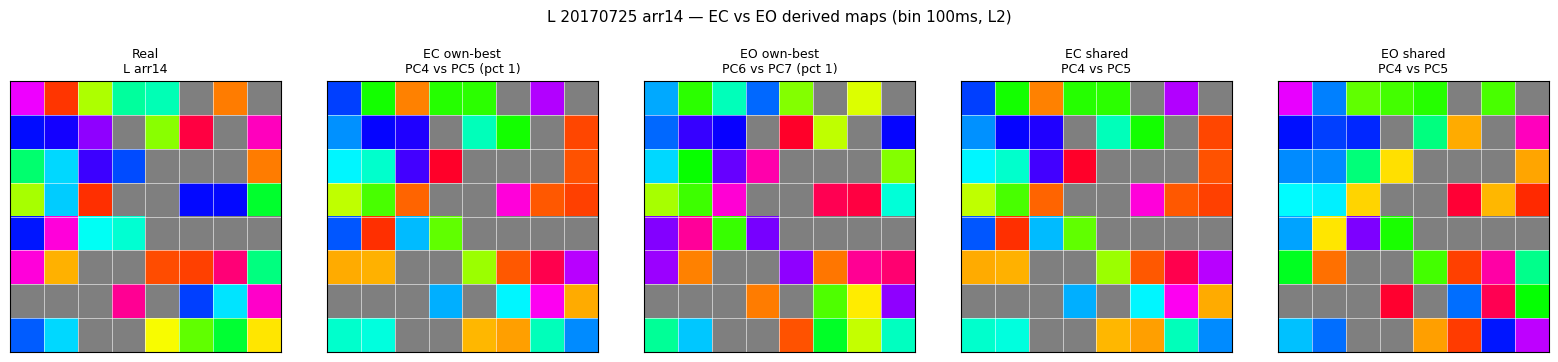

L 20170725 arr14: EC best PC4 vs PC5 | EO best PC6 vs PC7 | shared PC4 vs PC5


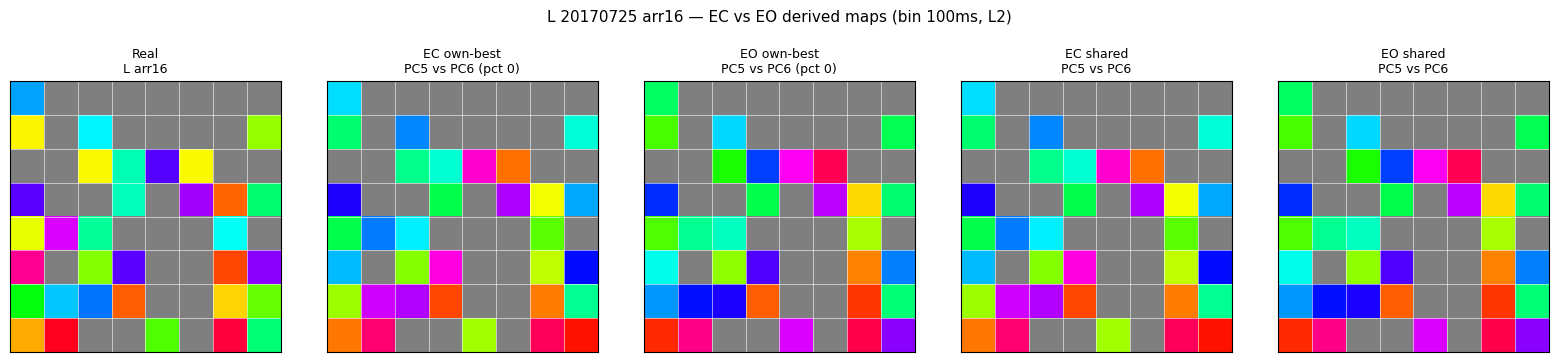

L 20170725 arr16: EC best PC5 vs PC6 | EO best PC5 vs PC6 | shared PC5 vs PC6


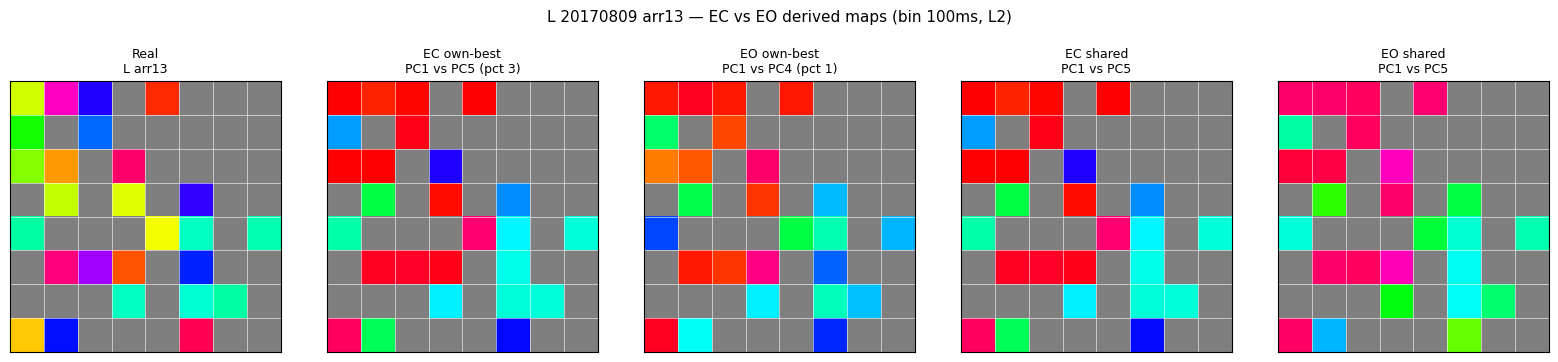

L 20170809 arr13: EC best PC1 vs PC5 | EO best PC1 vs PC4 | shared PC1 vs PC5


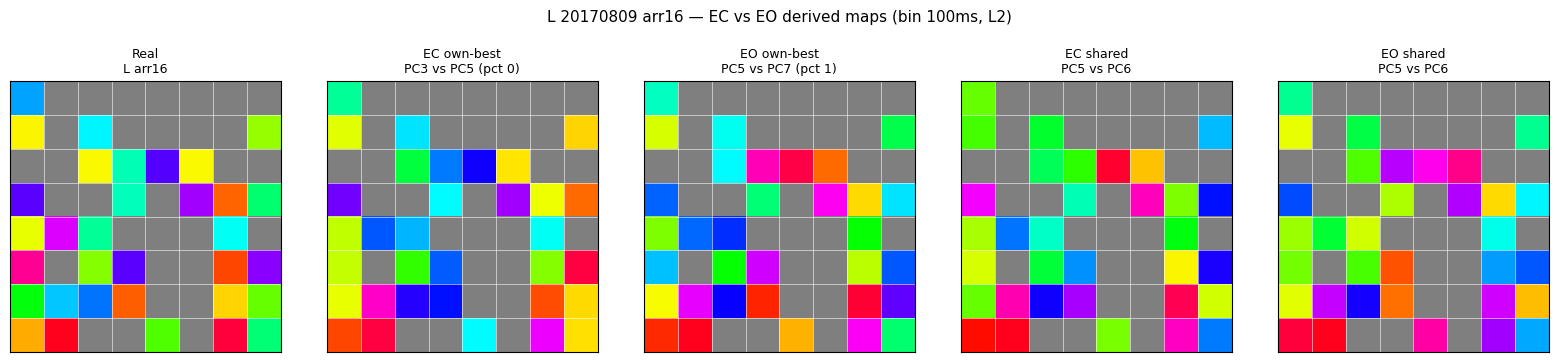

L 20170809 arr16: EC best PC3 vs PC5 | EO best PC5 vs PC7 | shared PC5 vs PC6


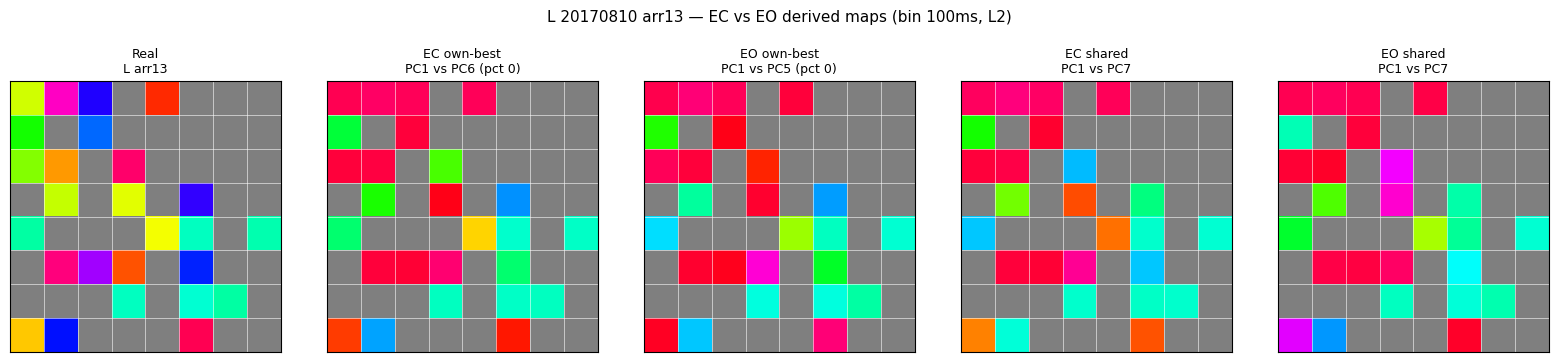

L 20170810 arr13: EC best PC1 vs PC6 | EO best PC1 vs PC5 | shared PC1 vs PC7


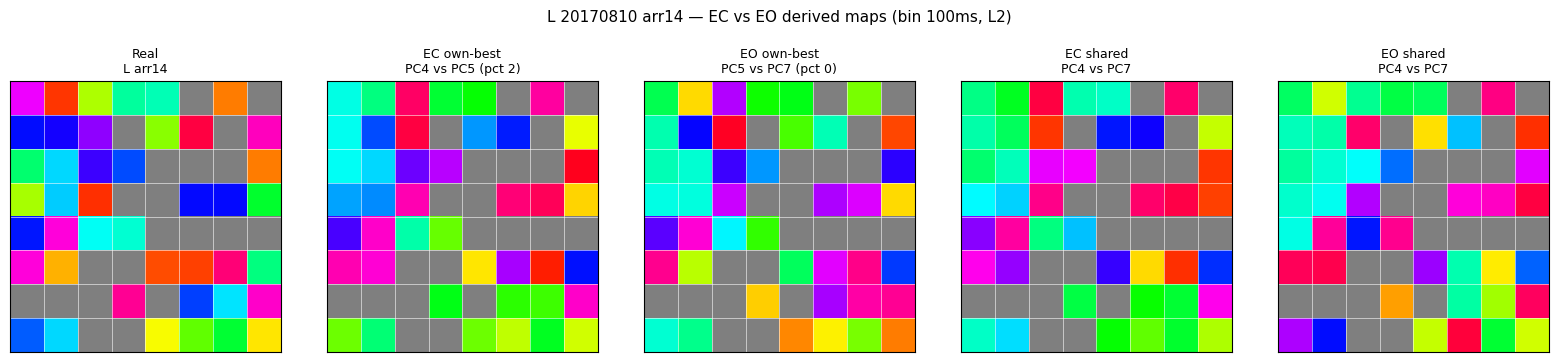

L 20170810 arr14: EC best PC4 vs PC5 | EO best PC5 vs PC7 | shared PC4 vs PC7


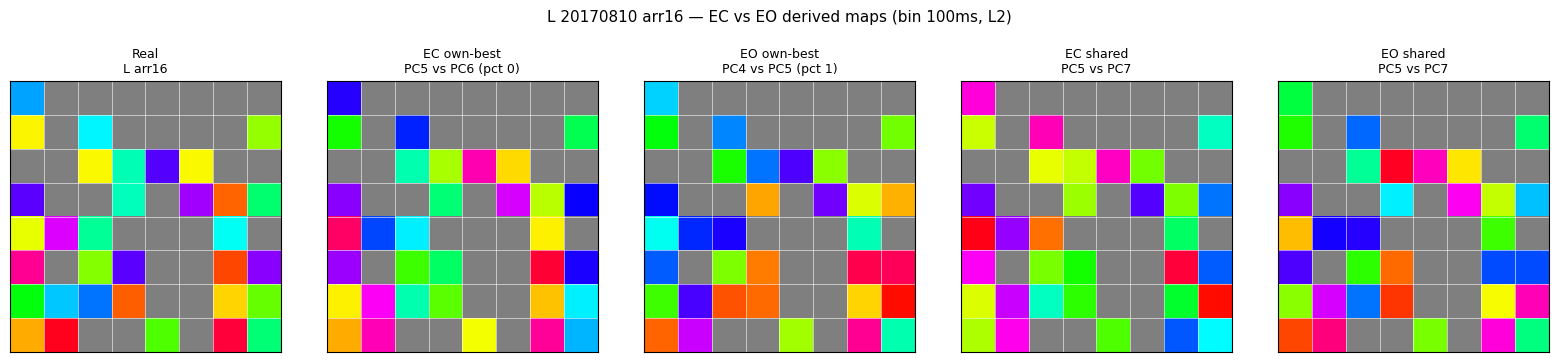

L 20170810 arr16: EC best PC5 vs PC6 | EO best PC4 vs PC5 | shared PC5 vs PC7


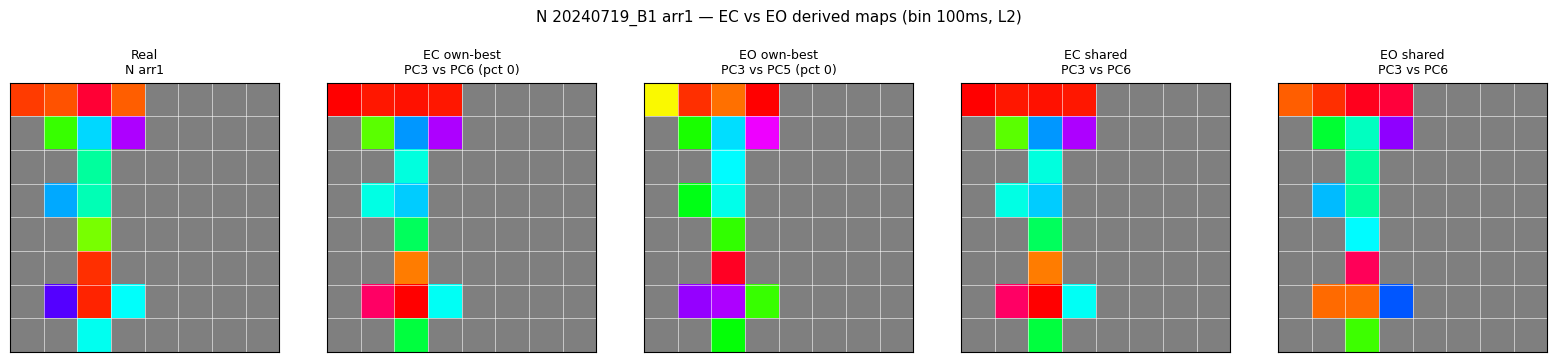

N 20240719_B1 arr1: EC best PC3 vs PC6 | EO best PC3 vs PC5 | shared PC3 vs PC6


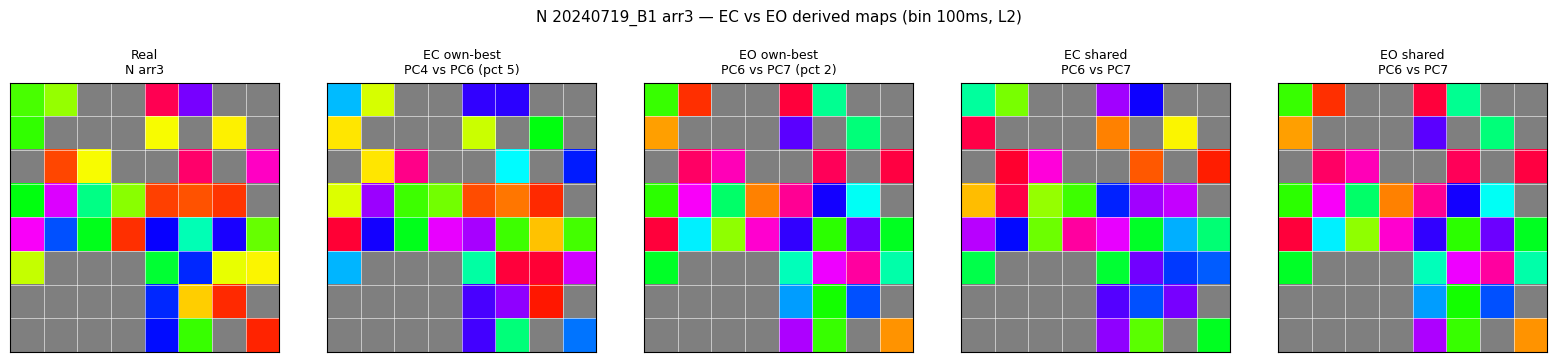

N 20240719_B1 arr3: EC best PC4 vs PC6 | EO best PC6 vs PC7 | shared PC6 vs PC7


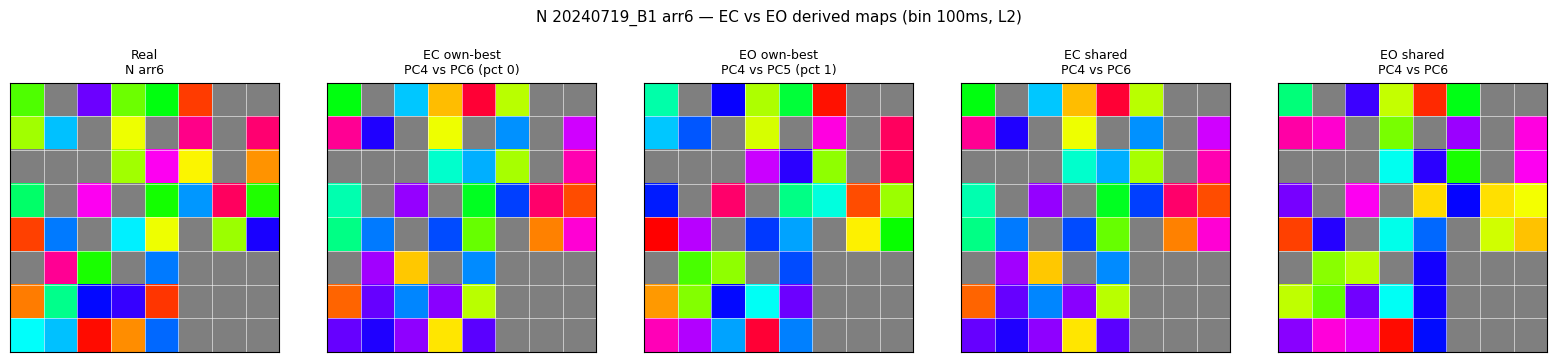

N 20240719_B1 arr6: EC best PC4 vs PC6 | EO best PC4 vs PC5 | shared PC4 vs PC6


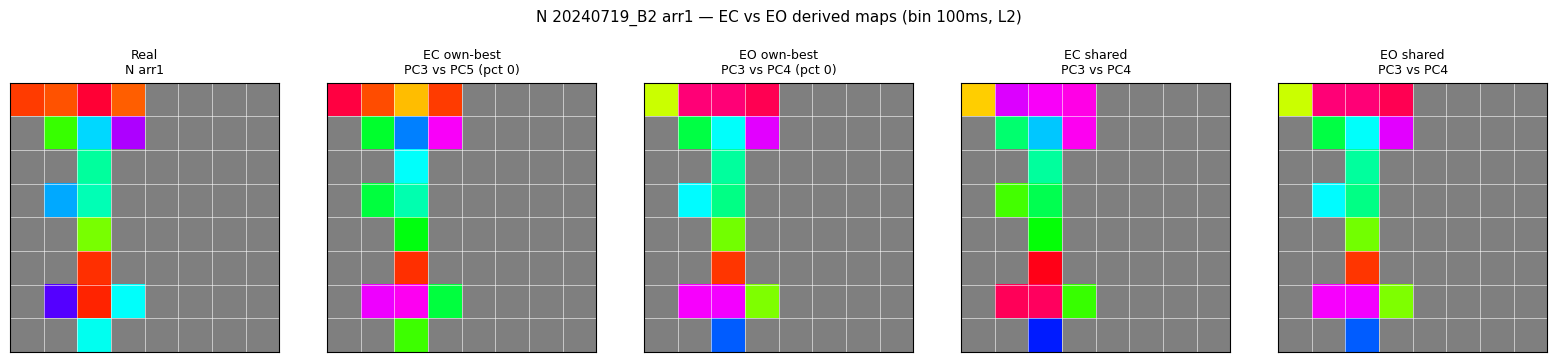

N 20240719_B2 arr1: EC best PC3 vs PC5 | EO best PC3 vs PC4 | shared PC3 vs PC4


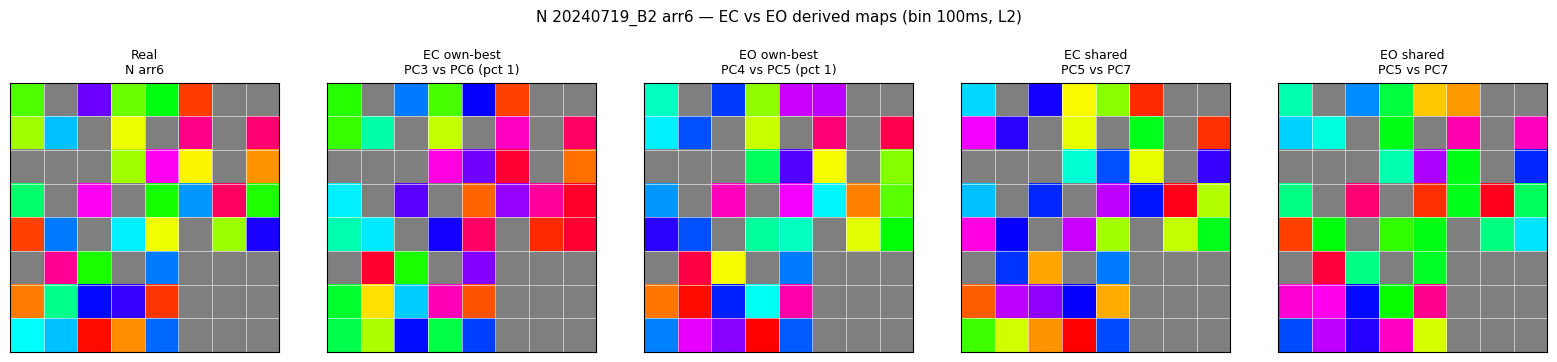

N 20240719_B2 arr6: EC best PC3 vs PC6 | EO best PC4 vs PC5 | shared PC5 vs PC7


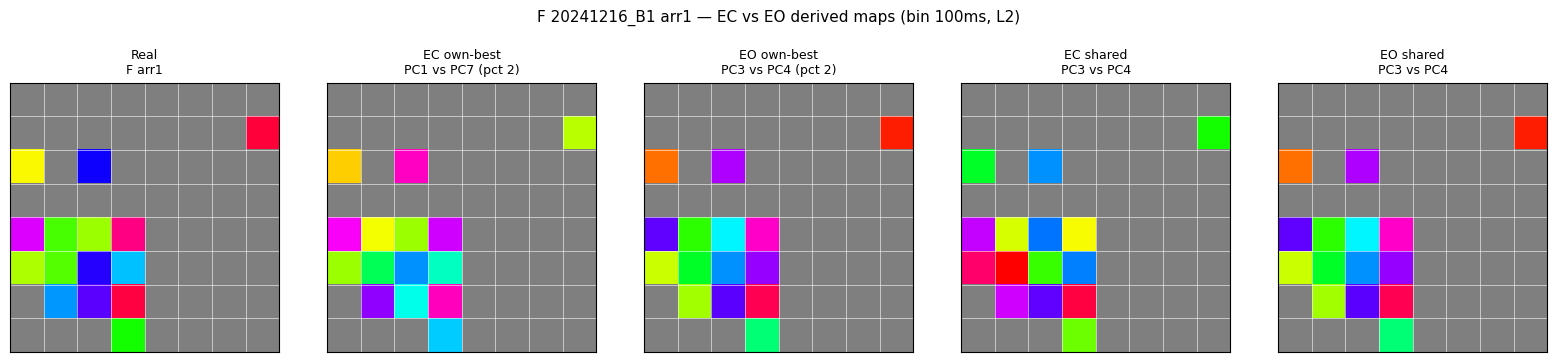

F 20241216_B1 arr1: EC best PC1 vs PC7 | EO best PC3 vs PC4 | shared PC3 vs PC4


In [9]:
def derived_for(monkey,date,array,condition,px,py):
    st=get_scores(monkey,date,array,condition,ECEO_BIN)
    op_full=load_op(monkey,array); oi=st["oriented_idx"]
    d=derived_map(st["scores"],oi,op_full[oi],px,py)
    return d, op_full

for (monkey,dt,arr,pec,peo) in qual:
    layout=get_layout(monkey,arr)
    bp_ec,_=best_pair(monkey,dt,arr,"EC",ECEO_BIN,ECEO_NPC)
    bp_eo,_=best_pair(monkey,dt,arr,"EO",ECEO_BIN,ECEO_NPC)
    # shared pair: lowest summed EC+EO error
    shared=None; best_s=np.inf
    for p in eceo_pairs:
        e1=real_err(monkey,dt,arr,"EC",ECEO_BIN,pair_label(*p))
        e2=real_err(monkey,dt,arr,"EO",ECEO_BIN,pair_label(*p))
        if not np.isnan(e1) and not np.isnan(e2) and (e1+e2)<best_s:
            best_s=e1+e2; shared=p

    d_ec,opf = derived_for(monkey,dt,arr,"EC",*bp_ec)
    d_eo,_   = derived_for(monkey,dt,arr,"EO",*bp_eo)
    d_ec_s,_ = derived_for(monkey,dt,arr,"EC",*shared)
    d_eo_s,_ = derived_for(monkey,dt,arr,"EO",*shared)

    fig,axes=plt.subplots(1,5,figsize=(16,3.4))
    draw_op_grid(axes[0],opf,layout,title=f"Real\n{monkey} arr{arr}")
    draw_op_grid(axes[1],d_ec,layout,title=f"EC own-best\n{pair_label(*bp_ec)} (pct {pec:.0f})")
    draw_op_grid(axes[2],d_eo,layout,title=f"EO own-best\n{pair_label(*bp_eo)} (pct {peo:.0f})")
    draw_op_grid(axes[3],d_ec_s,layout,title=f"EC shared\n{pair_label(*shared)}")
    draw_op_grid(axes[4],d_eo_s,layout,title=f"EO shared\n{pair_label(*shared)}")
    fig.suptitle(f"{monkey} {dt} arr{arr} — EC vs EO derived maps "
                 f"(bin {ECEO_BIN}ms, {NORM})",fontsize=11,y=1.05)
    plt.tight_layout(); plt.show()
    print(f"{monkey} {dt} arr{arr}: EC best {pair_label(*bp_ec)} | "
          f"EO best {pair_label(*bp_eo)} | shared {pair_label(*shared)}")

### EC vs EO — which pairs win (per-pair percentile profiles)

For the same qualifying cells, the per-pair percentile profile in EC vs EO side
by side, so you can see whether the informative projections coincide.

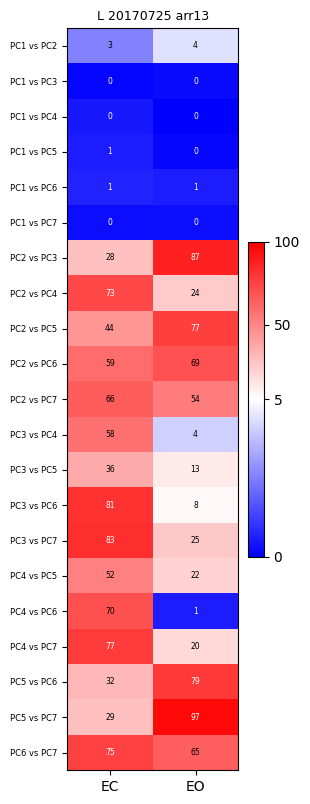

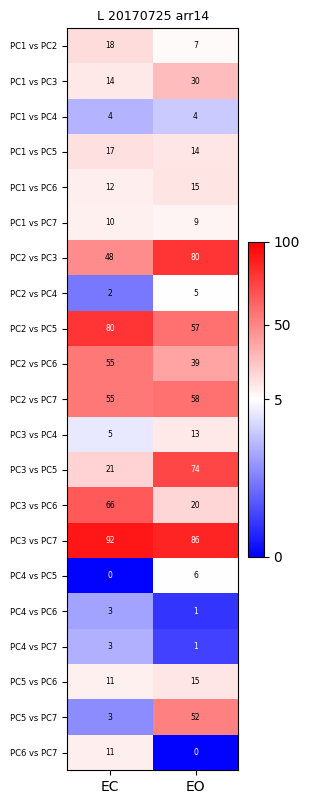

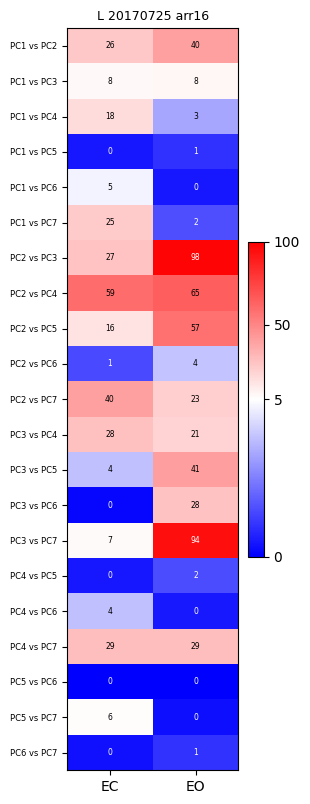

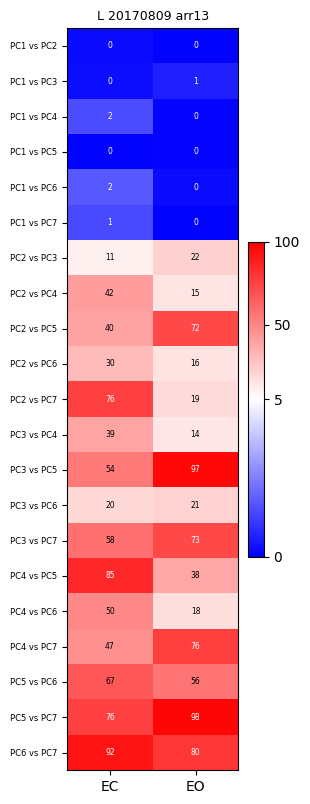

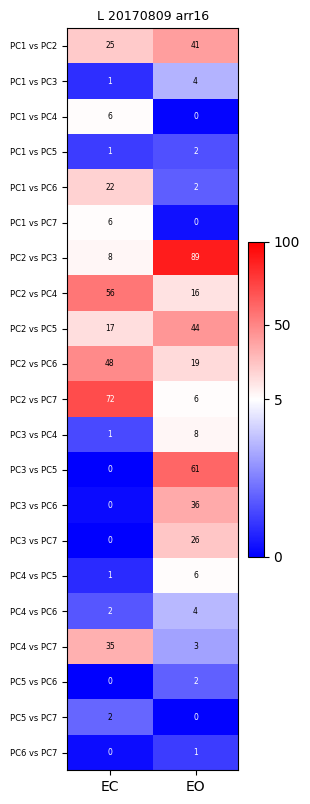

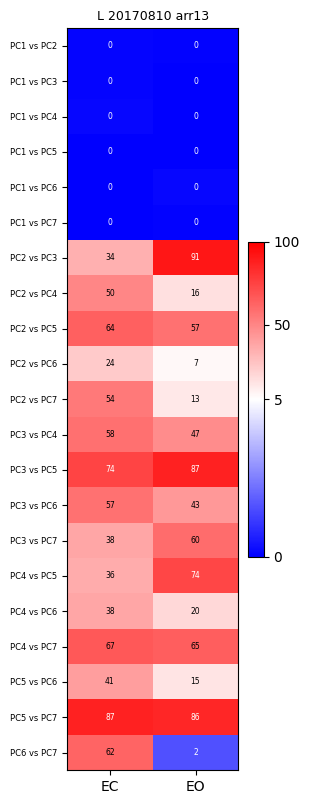

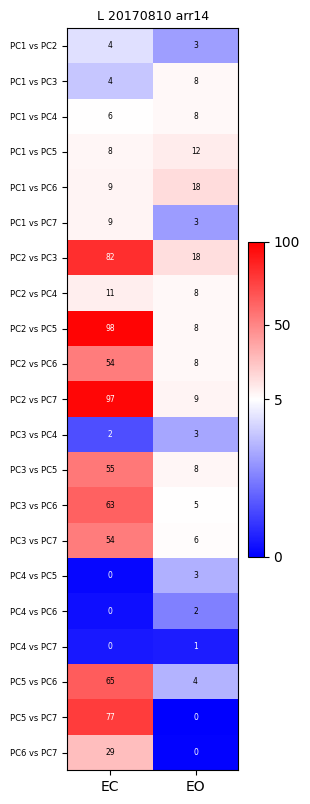

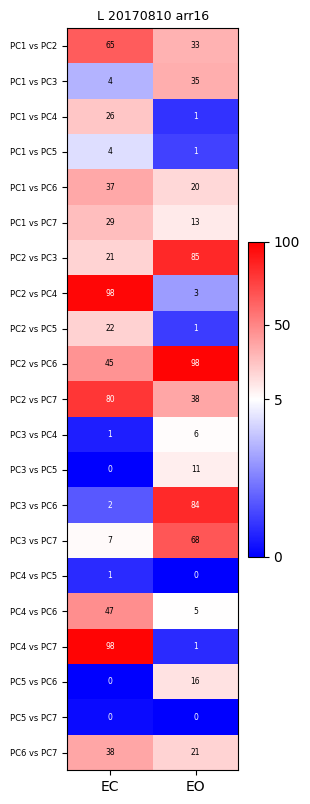

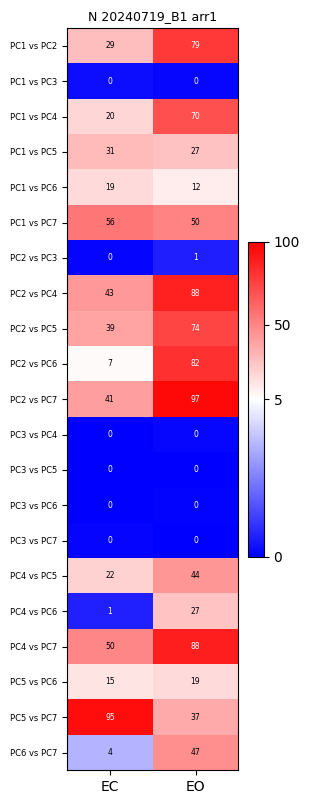

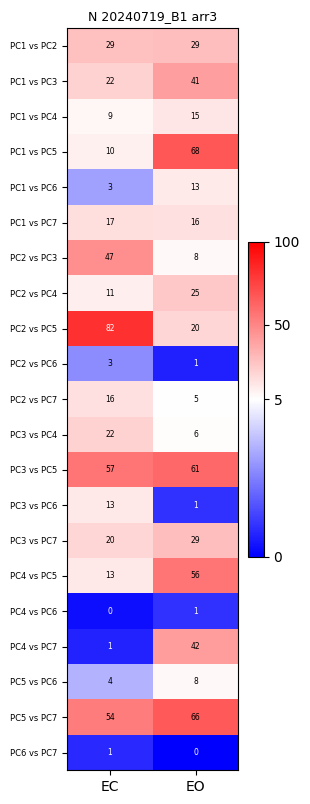

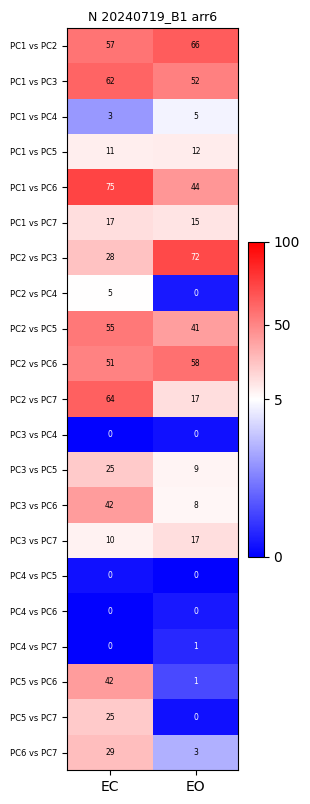

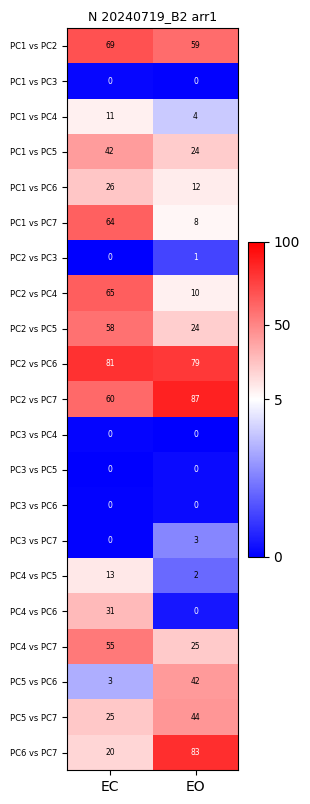

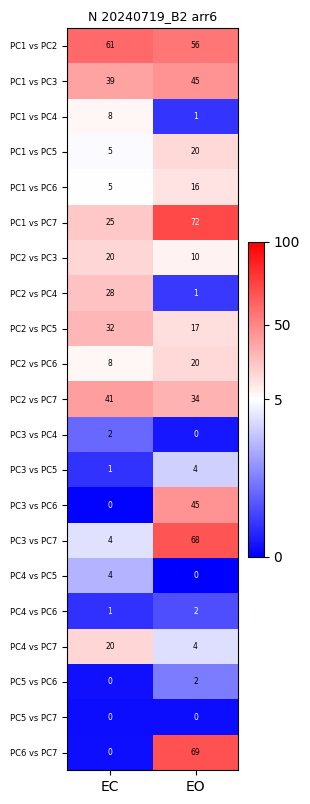

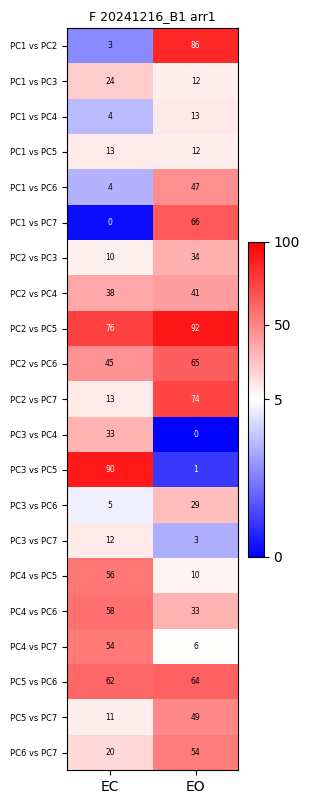

In [10]:
for (monkey,dt,arr,pec,peo) in qual:
    pp_ec=per_pair_percentile(monkey,dt,arr,"EC",ECEO_BIN,ECEO_NPC)
    pp_eo=per_pair_percentile(monkey,dt,arr,"EO",ECEO_BIN,ECEO_NPC)
    labels=[pair_label(*p) for p in eceo_pairs]
    M=np.array([[pp_ec[p][1] for p in eceo_pairs],
                [pp_eo[p][1] for p in eceo_pairs]]).T  # pairs x 2
    fig,ax=plt.subplots(figsize=(3.2, 0.34*len(eceo_pairs)+1))
    im=ax.imshow(M,cmap="bwr",norm=TwoSlopeNorm(vmin=0,vcenter=5,vmax=100),aspect="auto")
    ax.set_xticks([0,1]); ax.set_xticklabels(["EC","EO"])
    ax.set_yticks(range(len(eceo_pairs))); ax.set_yticklabels(labels,fontsize=6)
    ax.set_title(f"{monkey} {dt} arr{arr}",fontsize=9)
    for ir in range(len(eceo_pairs)):
        for jc in range(2):
            v=M[ir,jc]
            if not np.isnan(v):
                ax.text(jc,ir,f"{v:.0f}",ha="center",va="center",fontsize=5.5,
                        color="white" if (v<2 or v>70) else "black")
    fig.colorbar(im,ax=ax,fraction=0.08,pad=0.05,ticks=[0,5,50,100])
    plt.tight_layout(); plt.show()

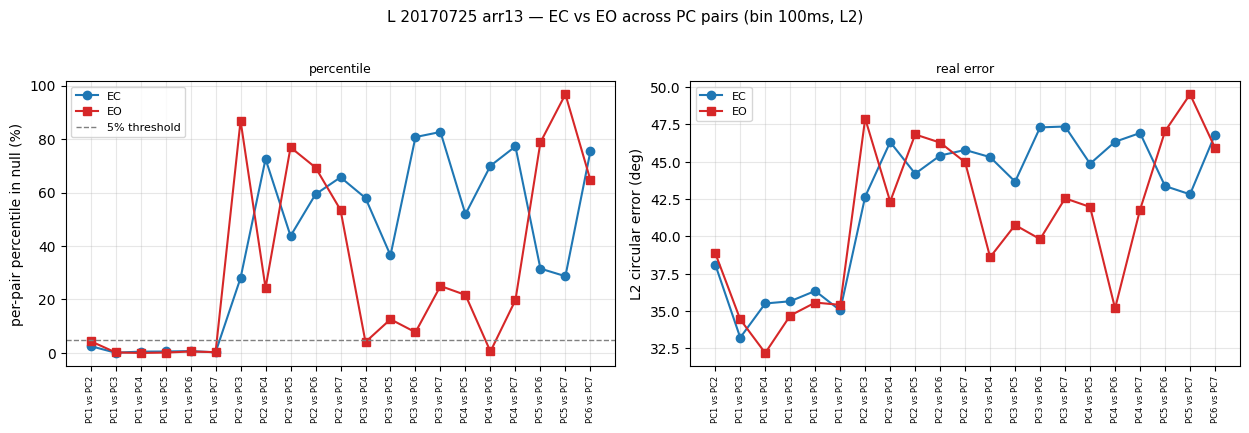

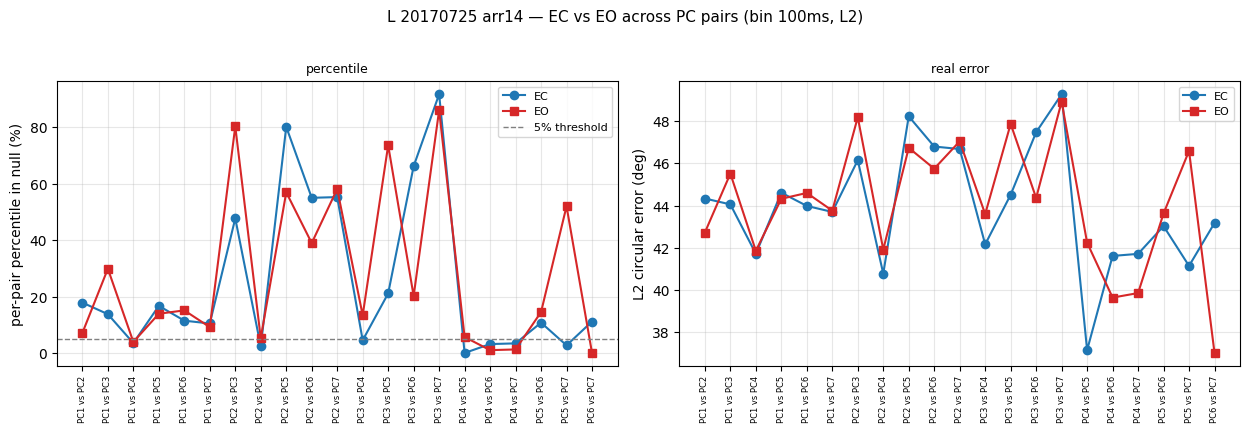

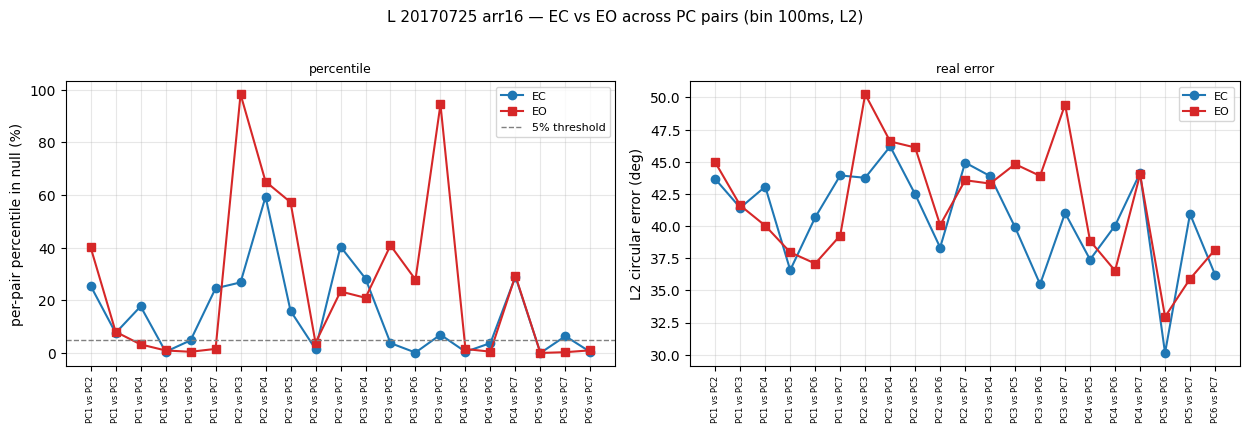

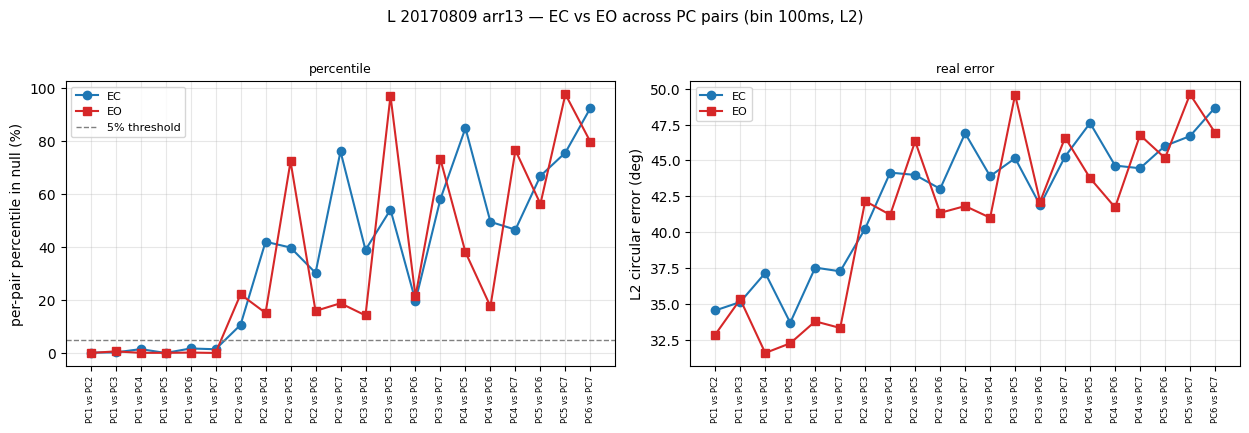

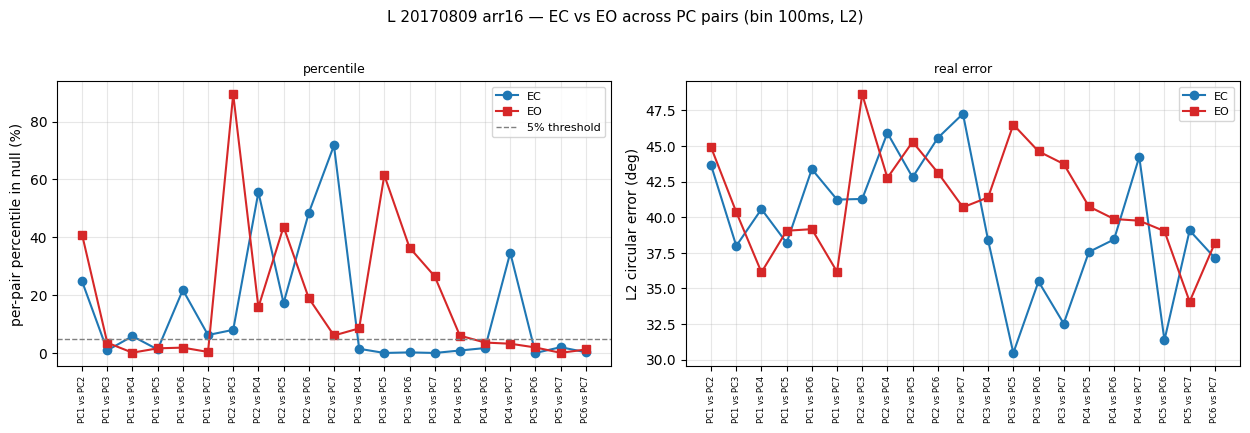

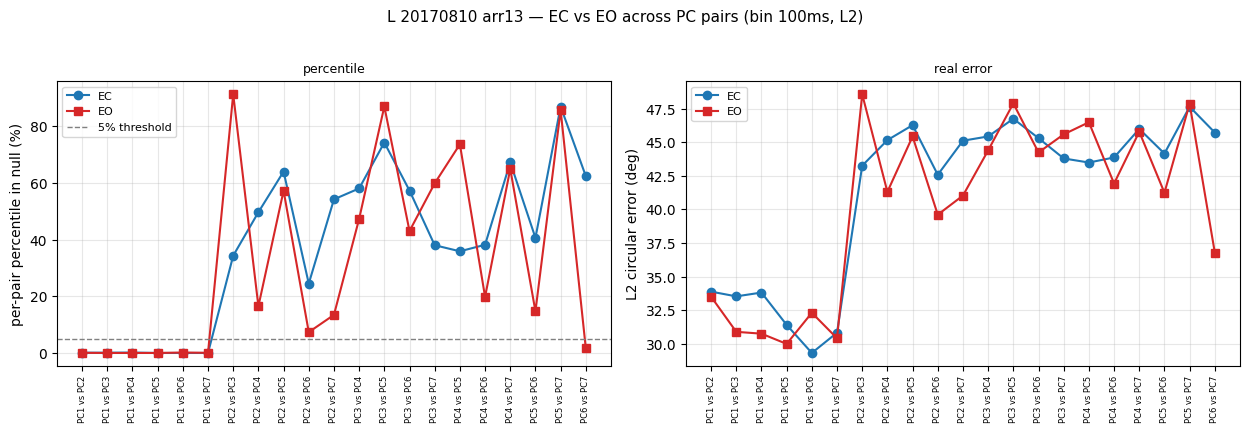

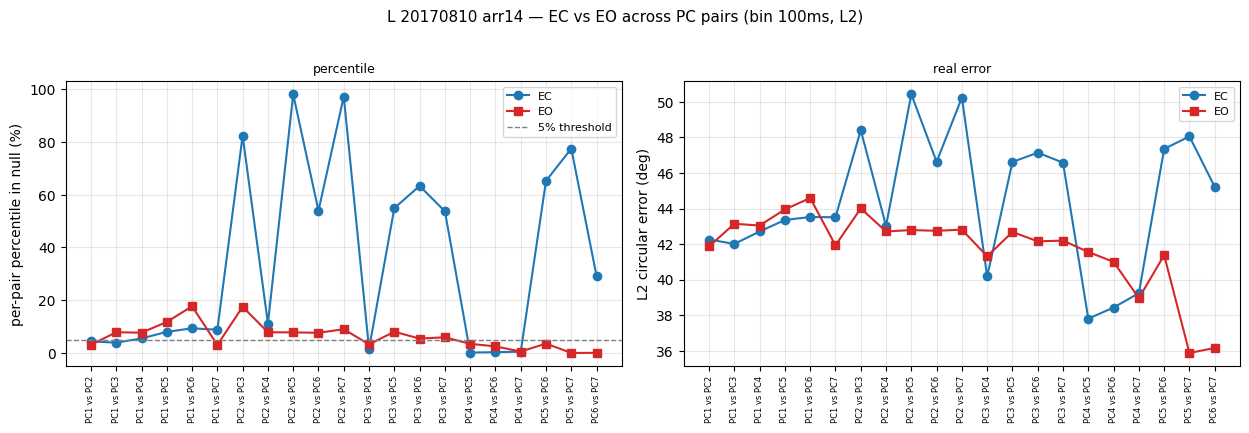

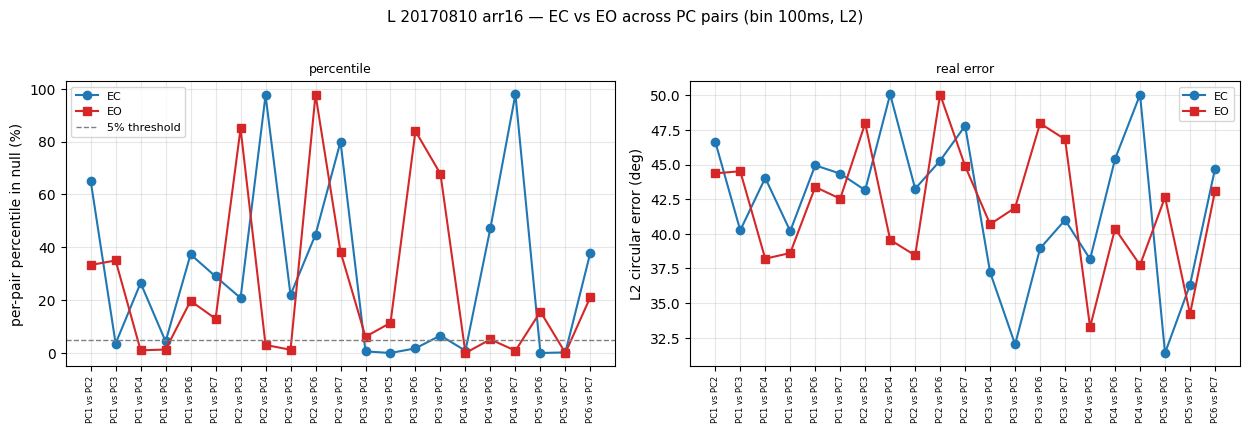

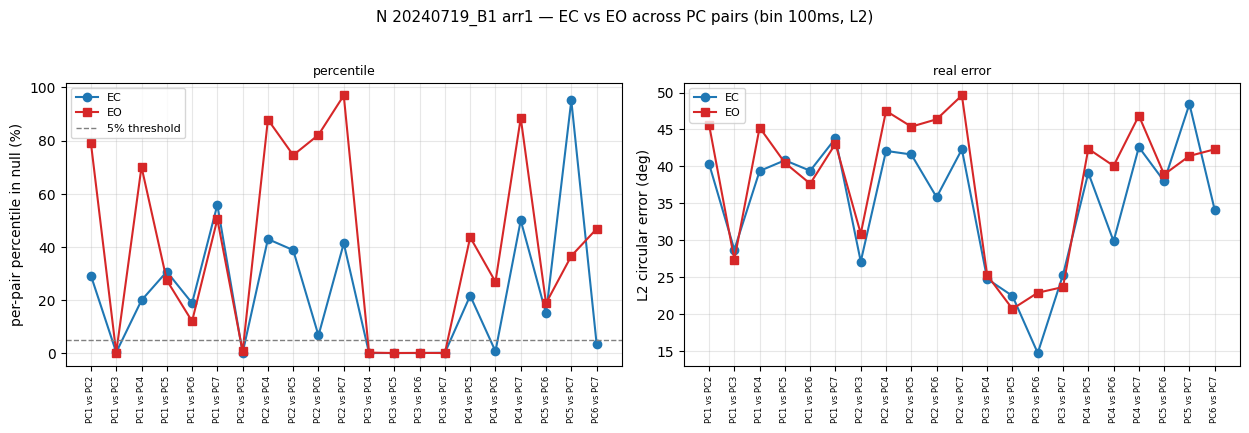

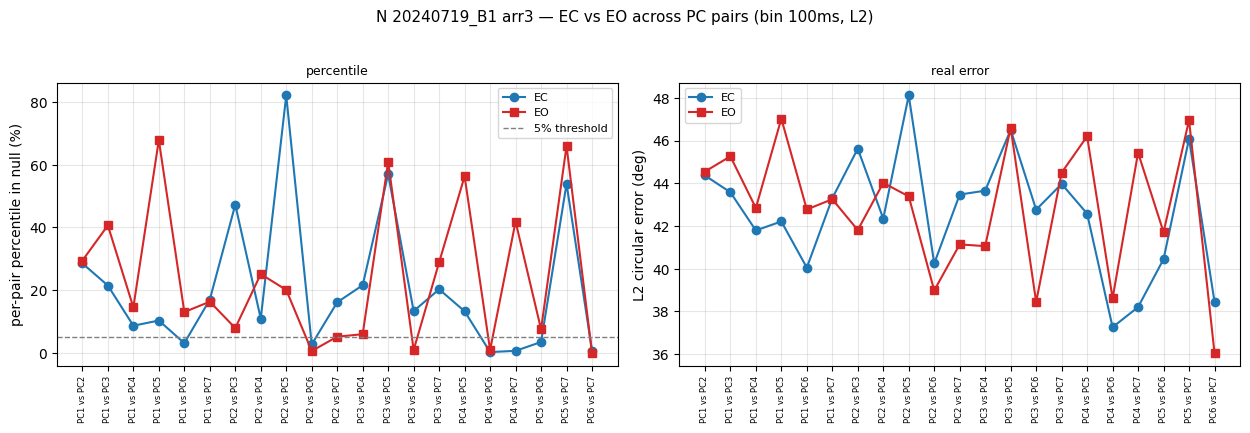

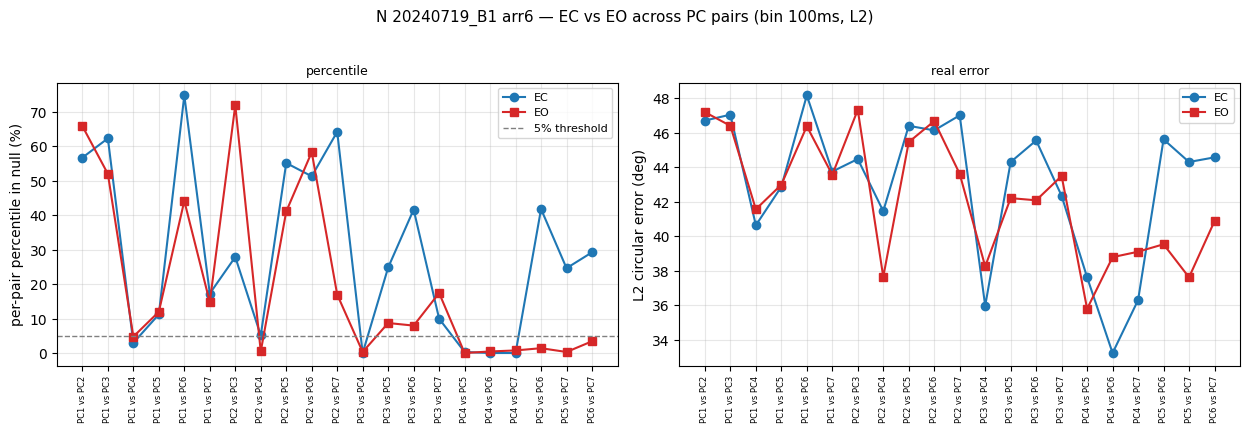

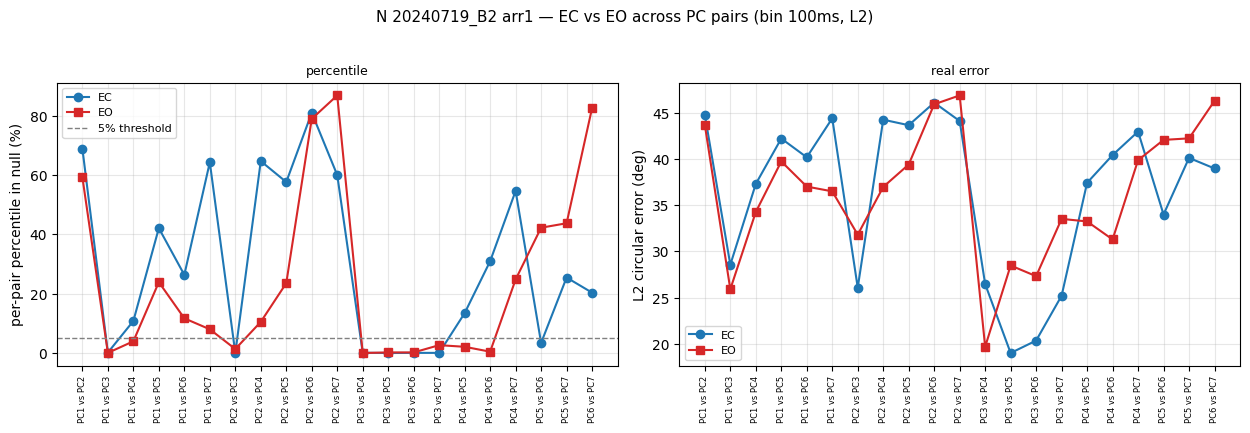

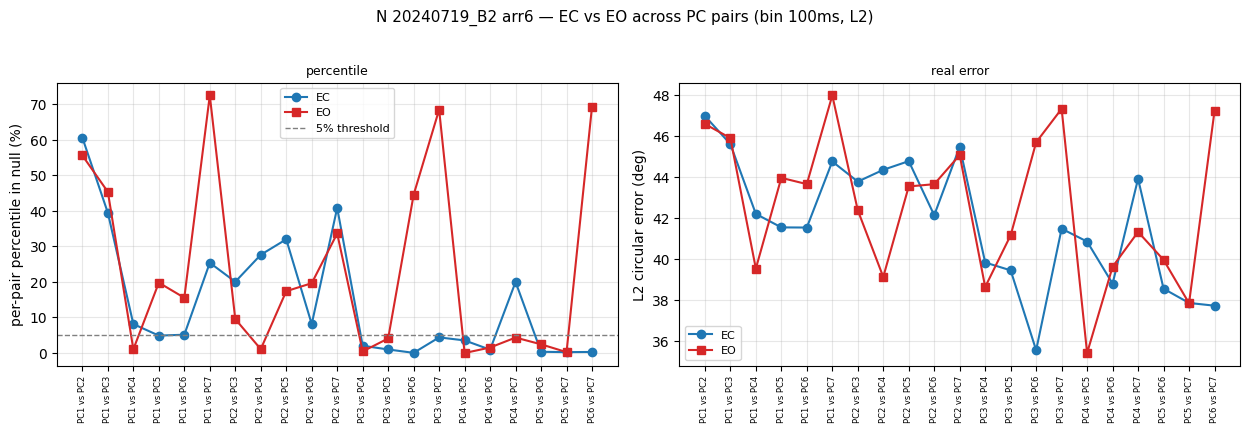

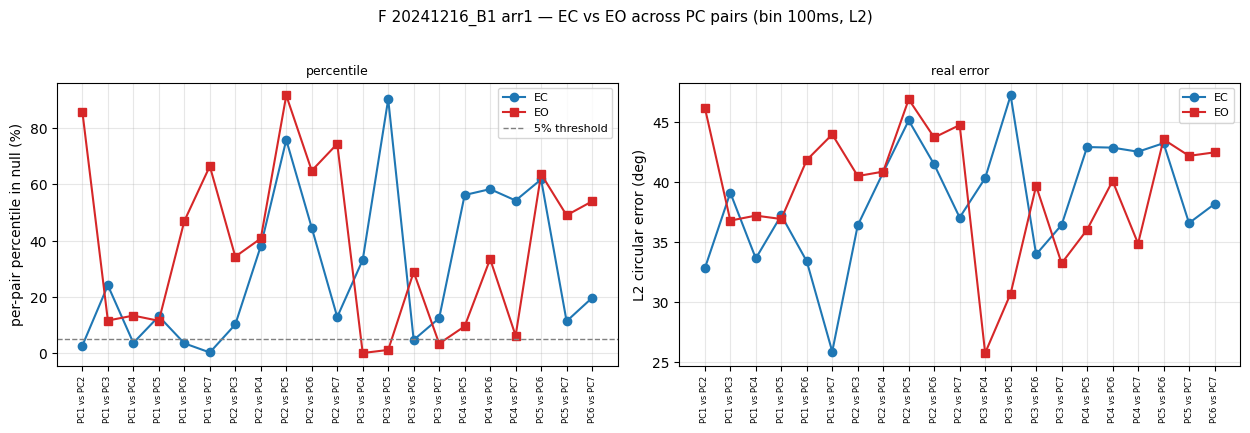

In [11]:
for (monkey, dt, arr, pec, peo) in qual:
    pp_ec = per_pair_percentile(monkey, dt, arr, "EC", ECEO_BIN, ECEO_NPC)
    pp_eo = per_pair_percentile(monkey, dt, arr, "EO", ECEO_BIN, ECEO_NPC)
    labels = [pair_label(*p) for p in eceo_pairs]
    x = range(len(eceo_pairs))

    pct_ec = [pp_ec[p][1] for p in eceo_pairs]
    pct_eo = [pp_eo[p][1] for p in eceo_pairs]
    err_ec = [pp_ec[p][0] for p in eceo_pairs]
    err_eo = [pp_eo[p][0] for p in eceo_pairs]

    fig, (axp, axe) = plt.subplots(1, 2, figsize=(max(9, len(eceo_pairs)*0.6), 4.2))

    # left: percentiles
    axp.plot(x, pct_ec, marker="o", lw=1.5, color="tab:blue", label="EC")
    axp.plot(x, pct_eo, marker="s", lw=1.5, color="tab:red", label="EO")
    axp.axhline(5, color="grey", ls="--", lw=1, label="5% threshold")
    axp.set_xticks(list(x)); axp.set_xticklabels(labels, rotation=90, fontsize=6)
    axp.set_ylabel("per-pair percentile in null (%)")
    axp.set_title("percentile", fontsize=9)
    axp.legend(fontsize=8); axp.grid(alpha=0.3)

    # right: real errors
    axe.plot(x, err_ec, marker="o", lw=1.5, color="tab:blue", label="EC")
    axe.plot(x, err_eo, marker="s", lw=1.5, color="tab:red", label="EO")
    axe.set_xticks(list(x)); axe.set_xticklabels(labels, rotation=90, fontsize=6)
    axe.set_ylabel(f"{NORM} circular error (deg)")
    axe.set_title("real error", fontsize=9)
    axe.legend(fontsize=8); axe.grid(alpha=0.3)

    fig.suptitle(f"{monkey} {dt} arr{arr} — EC vs EO across PC pairs "
                 f"(bin {ECEO_BIN}ms, {NORM})", fontsize=11, y=1.02)
    plt.tight_layout(); plt.show()

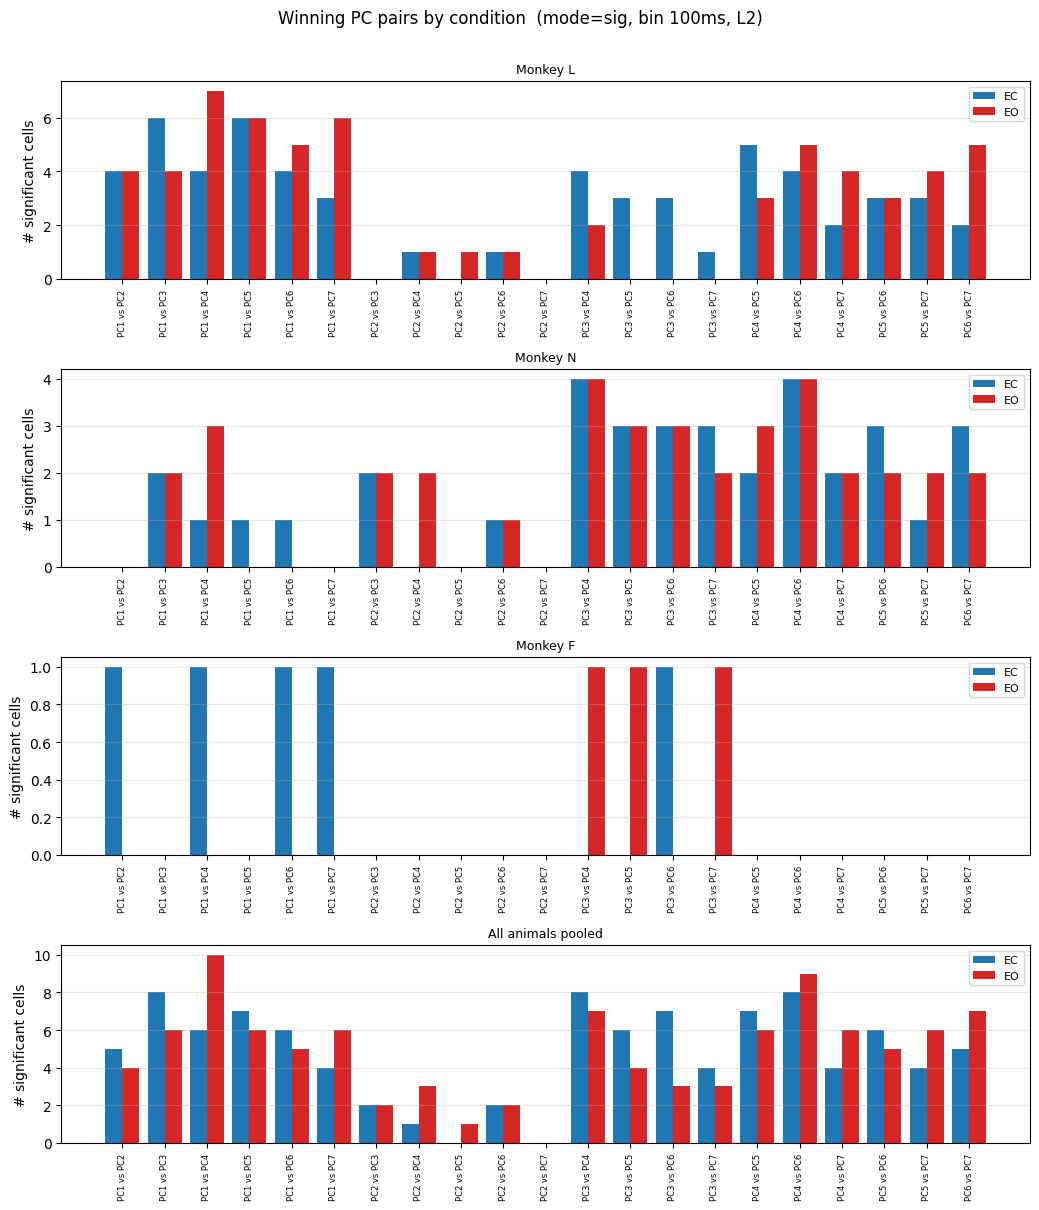

In [17]:
COUNT_MODE = "sig"     # "best" = single best pair per cell; "sig" = all pairs with pct<5
SIG_TH = 5.0

# tally winners per (animal, condition, pair)
labels = [pair_label(*p) for p in eceo_pairs]
tally = {m: {"EC": np.zeros(len(eceo_pairs)), "EO": np.zeros(len(eceo_pairs))}
         for m in MONKEYS}

for (monkey, dt, arr, pec, peo) in qual:
    for cond in ["EC", "EO"]:
        pp = per_pair_percentile(monkey, dt, arr, cond, ECEO_BIN, ECEO_NPC)
        errs = np.array([pp[p][0] for p in eceo_pairs])
        pcts = np.array([pp[p][1] for p in eceo_pairs])
        if COUNT_MODE == "best":
            if np.all(np.isnan(errs)):
                continue
            tally[monkey][cond][int(np.nanargmin(errs))] += 1
        else:  # "sig"
            for k in range(len(eceo_pairs)):
                if not np.isnan(pcts[k]) and pcts[k] < SIG_TH:
                    tally[monkey][cond][k] += 1

# across-animals total
tot = {"EC": sum(tally[m]["EC"] for m in MONKEYS),
       "EO": sum(tally[m]["EO"] for m in MONKEYS)}

def bar_panel(ax, ec_counts, eo_counts, title):
    x = np.arange(len(eceo_pairs)); w = 0.4
    ax.bar(x - w/2, ec_counts, width=w, color="tab:blue", label="EC")
    ax.bar(x + w/2, eo_counts, width=w, color="tab:red", label="EO")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=90, fontsize=6)
    ax.set_ylabel("# cells" if COUNT_MODE=="best" else "# significant cells")
    ax.set_title(title, fontsize=9); ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

n_panels = len(MONKEYS) + 1
fig, axes = plt.subplots(n_panels, 1, figsize=(max(9, len(eceo_pairs)*0.5), 3.0*n_panels))
for ax, monkey in zip(axes[:-1], MONKEYS):
    bar_panel(ax, tally[monkey]["EC"], tally[monkey]["EO"], f"Monkey {monkey}")
bar_panel(axes[-1], tot["EC"], tot["EO"], "All animals pooled")
fig.suptitle(f"Winning PC pairs by condition  "
             f"(mode={COUNT_MODE}, bin {ECEO_BIN}ms, {NORM})", fontsize=12, y=1.005)
plt.tight_layout(); plt.show()